# A4.1 — Estudo de caso: triagem de COVID-19 em radiografias de tórax

**Disciplina:** Visão Computacional com CNNs e Transformers [26E3_3] — INFNET · **Aluno:** Lucas de Oliveira Ferreira

**Contexto:** um grupo anterior entregou um classificador Normal / Pneumonia / COVID-19 "promissor", mas o time clínico relatou que o modelo **"ignora casos positivos"**. Configuração original: 1.200 raios-X (Normal 840, Pneumonia 240, COVID-19 120), divisão 80/20 sem estratificação, ResNet-18 **sem pré-treino**, SGD com LR fixo 0,01, 15 épocas, **sem augmentation**, avaliação só por **accuracy global**. Resultado: 93% de accuracy no treino, 61% na validação. O enunciado cita Nour & Tariq (2023, *Scientific Reports*) como evidência desse padrão em projetos reais: accuracy global alta com **recall < 60% para COVID-19** em dados desbalanceados, causado por augmentation insuficiente, desbalanceamento não tratado e métricas inadequadas.

> **Nota bibliográfica:** o link indicado no enunciado (doi:10.1038/s41598-023-37743-4) corresponde, segundo o Crossref e o Europe PMC, a *Dumakude, A.; Ezugwu, A. E. "Automated COVID-19 detection with convolutional neural networks", Scientific Reports 13, 10607 (2023)*, um trabalho com tomografias (CovidxCT-2A) que reporta métricas por classe (precision, recall, specificity, F1) além da accuracy. Citamos o artigo pelo DOI fornecido e atribuímos ao enunciado a afirmação sobre recall < 60%.

**Neste notebook:** (1) diagnóstico dos problemas; (2) reprodução do baseline falho; (3) **GAN condicional (cGAN, estilo DCGAN)** para gerar raios-X sintéticos de COVID-19; (4) experimento controlado **com × sem imagens sintéticas**, medindo o **recall da classe COVID-19**; (5) plano de melhoria integrado.

**Dataset:** [COVID-19 Radiography Database](https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database) (Chowdhury et al., 2020; Rahman et al., 2021). Amostramos, com semente fixa, o cenário do enunciado: **Normal 840, Pneumonia viral 240, COVID-19 120**.

| Requisito | Valor estimado (Colab T4) |
|---|---|
| GPU | T4 — pico ~3 GB de VRAM |
| RAM | ~4 GB |
| Disco | ~1,0 GB temporário (zip de 816 MB; extraímos só ~2.400 PNGs ≈ 150 MB) |
| Tempo total | ~45–55 min no T4 (download ~2 min, baseline ~1 min, cGAN ~13 min, ablação de estabilização ~17 min, FID ~1 min, 12 treinos do classificador ~18 min) |

**Como rodar:** T4 GPU → `Executar tudo`. Sem Drive e sem `kaggle.json`. O checkpoint do gerador é salvo em `DATA_ROOT` (em `/content`); para preservá-lo entre sessões, monte o Drive e aponte `DATA_ROOT` para ele (opcional).

**Uso de IA:** código e texto elaborados com apoio do Claude (Anthropic), revisados e executados pelo aluno; números e figuras são outputs reais deste notebook.

**Base nas aulas:** Aula 07 (DCGAN, cGAN, perda não-saturante, TTUR, *label smoothing* unilateral, *instance noise*, *spectral norm*, *mode collapse*, validação pelo recall *downstream*), Aula 08 (FID com N reportado, ΔRecall, sintéticas só no treino e teste 100% real, sem flip horizontal em imagem médica assimétrica, split estratificado, paradoxo da acurácia, balanced accuracy), Aula 01 (transfer learning com TorchVision).

## 0. Setup

In [1]:
import os, sys, subprocess, time, json, math, random, zipfile, shutil, urllib.request, copy
from pathlib import Path

try:
    import torch_fidelity
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-fidelity"], check=True)
    import torch_fidelity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from torch.nn.utils import spectral_norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_fscore_support, f1_score)

IN_COLAB = "google.colab" in sys.modules
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/content/data" if IN_COLAB else "data")).resolve()
FIG_DIR = Path(os.environ.get("FIG_DIR", "figs/A4")).resolve(); FIG_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

CLASSES = ["Normal", "Pneumonia", "COVID-19"]
SRC_DIRS = {"Normal": "Normal", "Pneumonia": "Viral Pneumonia", "COVID-19": "COVID"}
CONFIG = dict(
    seed=42, img=128, n_per_class={"Normal": 840, "Pneumonia": 240, "COVID-19": 120},
    n_extra_test={"Normal": 600, "Pneumonia": 300, "COVID-19": 600},     # teste ampliado (imagens reais fora das 1.200)
    gan=dict(nz=100, emb=16, iters=6000, ablation_iters=2500, batch=64, lr_g=1e-4, lr_d=4e-4, betas=(0.5, 0.999), real_label=0.9, noise_sigma0=0.1),
    clf=dict(epochs=12, batch=32, lr_backbone=1e-4, lr_head=1e-3, wd=1e-4, seeds=[0, 1, 2]),
    synth_sizes={"B1": 252, "B2": 504},
)
seed_everything(CONFIG["seed"])
print("torch", torch.__version__, "| device", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

torch 2.14.1+cu126 | device cuda | NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 1. Dados: amostragem do cenário do enunciado

A base completa tem 10.192 Normal, 1.345 Pneumonia viral e 3.616 COVID-19. Sorteamos (semente 42) **exatamente 840 / 240 / 120** para reproduzir o projeto analisado. Além disso, separamos um **teste ampliado** com imagens reais que **não** fazem parte das 1.200 (600 Normal, 300 Pneumonia, 600 COVID-19): com só 18 COVID-19 no teste do cenário, cada caso vale 5,6 pontos percentuais de recall; o teste ampliado dá estimativas muito mais estáveis. Todas as imagens são convertidas para tons de cinza e reduzidas para **128×128** — a mesma resolução que a GAN vai gerar, para que reais e sintéticas passem pelo mesmo pipeline (se as sintéticas tivessem resolução diferente, o classificador poderia aprender "imagem borrada ⇒ COVID", um atalho).

In [2]:
class Archive:
    def __init__(self, path):
        self.path = Path(path); self.zf = zipfile.ZipFile(self.path) if self.path.is_file() else None
    def names(self):
        if self.zf: return [n for n in self.zf.namelist() if not n.endswith("/")]
        return [p.relative_to(self.path).as_posix() for p in self.path.rglob("*") if p.is_file()]
    def open(self, name):
        return self.zf.open(name) if self.zf else open(self.path / name, "rb")

def kaggle_archive(ref, name):
    zpath = DATA_ROOT / "_zips" / f"{name}.zip"
    if zpath.exists(): return Archive(zpath)
    zpath.parent.mkdir(parents=True, exist_ok=True)
    try:
        with urllib.request.urlopen(f"https://www.kaggle.com/api/v1/datasets/download/{ref}", timeout=900) as r, \
             open(f"{zpath}.part", "wb") as f:
            shutil.copyfileobj(r, f, 1 << 20)
        os.replace(f"{zpath}.part", zpath); return Archive(zpath)
    except Exception as e:
        print("Download anônimo falhou:", e, "→ kagglehub"); import kagglehub
        return Archive(kagglehub.dataset_download(ref))

COVID_DIR = DATA_ROOT / "covid_sample"
manifest_path = COVID_DIR / "manifest.csv"
if not manifest_path.exists():
    arc = kaggle_archive("tawsifurrahman/covid19-radiography-database", "covid")
    names = arc.names()
    rng = np.random.RandomState(CONFIG["seed"])
    rows = []
    for c in CLASSES:
        pool = sorted(n for n in names if f"/{SRC_DIRS[c]}/images/" in n and n.endswith(".png"))
        pick = rng.choice(len(pool), CONFIG["n_per_class"][c] + CONFIG["n_extra_test"][c], replace=False)
        for k, i in enumerate(pick):
            rows.append(dict(member=pool[i], label=c, conjunto="cenario" if k < CONFIG["n_per_class"][c] else "teste_ampliado"))
    COVID_DIR.mkdir(parents=True, exist_ok=True)
    for r in rows:
        with arc.open(r["member"]) as f:
            im = Image.open(f).convert("L").resize((CONFIG["img"], CONFIG["img"]), Image.BICUBIC)
        out = COVID_DIR / r["label"] / Path(r["member"]).name; out.parent.mkdir(exist_ok=True); im.save(out)
        r["path"] = str(out.relative_to(COVID_DIR))
    for n in names:
        if n.endswith(".metadata.xlsx"):
            with arc.open(n) as f, open(COVID_DIR / Path(n).name, "wb") as g: shutil.copyfileobj(f, g)
    pd.DataFrame(rows).to_csv(manifest_path, index=False)
meta = pd.read_csv(manifest_path)
meta["path"] = meta.path.map(lambda p: str(COVID_DIR / p))
meta["y"] = meta.label.map({c: i for i, c in enumerate(CLASSES)})
pd.crosstab(meta.label, meta.conjunto).loc[CLASSES]

conjunto,cenario,teste_ampliado
label,,
Normal,840,600
Pneumonia,240,300
COVID-19,120,600


### Origem das imagens: um risco de *shortcut* antes mesmo de treinar

O arquivo de metadados informa de qual repositório/hospital veio cada imagem. Se cada classe vem de fontes diferentes, um modelo pode aprender a reconhecer **a fonte** (equipamento, marcações, contraste, recorte) em vez da doença — e falhar em outro hospital.

In [3]:
src = []
for c in CLASSES:
    m = pd.read_excel(COVID_DIR / f"{SRC_DIRS[c]}.metadata.xlsx")
    m["stem"] = m["FILE NAME"].astype(str).str.strip().str.lower(); m["fonte"] = m["URL"].astype(str).str.replace(r"https?://(www\.)?", "", regex=True).str.split("/").str[:2].str.join("/")
    src.append(m[["stem", "fonte"]].assign(label=c))
src = pd.concat(src).drop_duplicates(["stem", "label"])
meta["stem"] = meta.path.map(lambda p: Path(p).stem.lower())
meta = meta.merge(src, on=["stem", "label"], how="left")
fontes = pd.crosstab(meta[meta.conjunto == "cenario"].fonte.fillna("desconhecida"), meta[meta.conjunto == "cenario"].label)[CLASSES]
fontes

label,Normal,Pneumonia,COVID-19
fonte,,,
bimcv.cipf.es/bimcv-projects,0,0,72
eurorad.org,0,0,13
github.com/armiro,0,0,18
github.com/ieee8023,0,0,8
github.com/ml-workgroup,0,0,6
kaggle.com/c,732,0,0
kaggle.com/paultimothymooney,108,240,0
sirm.org/category,0,0,3


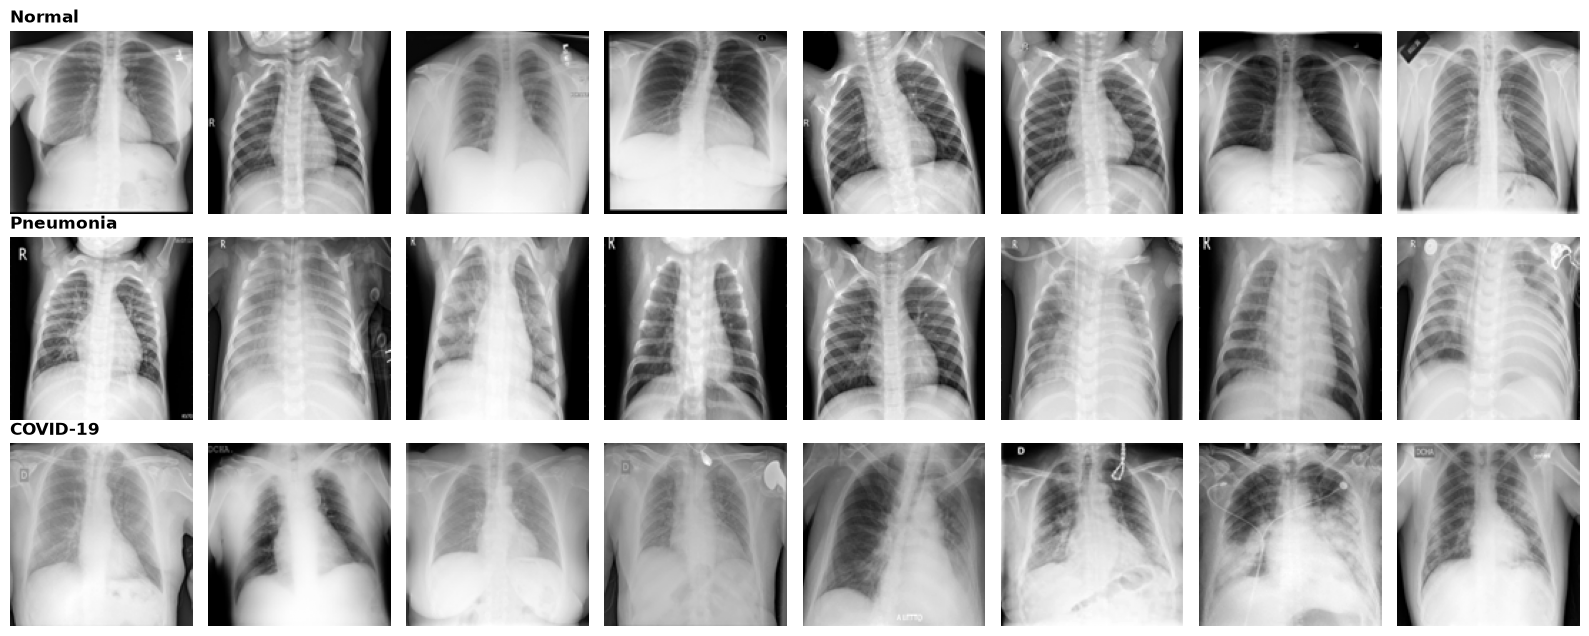

In [4]:
imgs = {r.path: np.asarray(Image.open(r.path), dtype=np.uint8) for r in meta.itertuples()}
fig, axes = plt.subplots(3, 8, figsize=(16, 6.4))
for i, c in enumerate(CLASSES):
    for j, p in enumerate(meta[(meta.label == c) & (meta.conjunto == "cenario")].sample(8, random_state=1).path):
        axes[i, j].imshow(imgs[p], cmap="gray"); axes[i, j].axis("off")
    axes[i, 0].set_title(c, loc="left", fontweight="bold")
plt.tight_layout(); savefig("01_exemplos_reais"); plt.show()

## 2. Diagnóstico do projeto anterior

A queixa clínica ("o modelo ignora casos positivos") e os números (93% de treino, 61% de validação) são consistentes com um modelo que **decorou o treino e, na dúvida, prevê a classe majoritária (Normal)**. Com 70% de imagens Normais, prever "Normal" para tudo já dá 70% de accuracy: a accuracy global não consegue revelar esse comportamento. A tabela lista os problemas, a evidência de cada um e o impacto clínico esperado.

| # | Problema | Evidência no projeto | Impacto clínico esperado | Correção |
|---|---|---|---|---|
| 1 | **ResNet-18 sem pré-treino** com 1.200 imagens | 11,7 M parâmetros aprendidos do zero com ~960 imagens de treino | O modelo não aprende bordas e texturas gerais, decora o treino e generaliza mal para radiografias novas: diagnósticos instáveis | *Transfer learning* do ImageNet (Aula 01), *fine-tuning* com LR baixo |
| 2 | **Overfitting** | 93% no treino vs 61% na validação (gap de 32 p.p.) | O desempenho em produção fica perto dos 61%, ou pior: o "promissor" é ilusório | Pré-treino, augmentation, regularização, *early stopping* pela validação |
| 3 | **Sem augmentation** | Cada imagem é vista sempre igual nas 15 épocas | O modelo não fica robusto a variações de posicionamento, exposição e equipamento; falha em outro hospital | Augmentation **clinicamente válida**: rotação leve, recorte leve, brilho/contraste; **sem flip horizontal**, porque o coração fica à esquerda (Aula 08) |
| 4 | **Desbalanceamento não tratado** (70/20/10) | Normal 840 vs COVID-19 120 (7:1) | A *loss* é dominada pela classe Normal, e o modelo aprende que errar COVID-19 "custa pouco". **Falsos negativos de COVID-19**: pacientes infectados liberados sem isolamento nem tratamento | Rebalancear: dados sintéticos (cGAN), pesos por classe, *oversampling*, limiar calibrado |
| 5 | **Divisão 80/20 sem estratificação** | A validação recebe por sorteio ~24 COVID-19, que podem ser 15 ou 30 | A métrica de COVID-19 vira loteria e as decisões do projeto (parar, publicar) são tomadas sobre ruído | `train_test_split(..., stratify=y)` (Aula 08) e repetição com várias sementes |
| 6 | **Accuracy global como única métrica** | "61%" sem recall por classe | **Paradoxo da acurácia** (Aula 08): a métrica fica alta mesmo com recall de COVID-19 baixo, e o problema que o time clínico viu fica invisível no relatório técnico | Recall/sensibilidade por classe (**métrica primária: recall de COVID-19**), especificidade, F1, balanced accuracy, matriz de confusão |
| 7 | **SGD com LR fixo 0,01 e 15 épocas arbitrárias** | Sem *scheduler*, sem *warmup*, sem critério de parada | LR alto e fixo oscila em torno do mínimo; sem *early stopping*, o modelo final é o da época 15, não o melhor. Resultado não reprodutível | AdamW/SGD com *cosine* ou *one-cycle*, seleção da época pela validação (macro-F1 ou recall de COVID-19) |
| 8 | **Sem conjunto de teste independente** | A validação serve para ajustar **e** para reportar | O número reportado é otimista (viés de seleção); não existe estimativa honesta do desempenho em produção | Divisão treino/validação/teste (70/15/15), com o teste usado **uma vez** |
| 9 | **Possível vazamento por paciente e viés de fonte** | Bases públicas misturam várias imagens por paciente e as classes vêm de **repositórios diferentes** (ver tabela de fontes acima) | O modelo pode reconhecer o hospital, a marcação ou o equipamento em vez da doença (*shortcut*). Métrica inflada, falha silenciosa em outro hospital | `GroupKFold` por paciente (Aula 08), validação externa multicêntrica, auditoria com mapas de atenção/Grad-CAM |
| 10 | **Limiar de decisão não calibrado** | `argmax` padrão | Em triagem, falso negativo é muito mais caro que falso positivo, mas o limiar padrão trata os dois igualmente | Escolher o limiar na validação para uma **sensibilidade-alvo** (ex.: ≥ 95%) e reportar a especificidade correspondente |

Abaixo, reproduzimos o baseline para **mostrar** os problemas 1, 2, 5 e 6 em ação.

## 3. Reprodução do baseline falho

Reproduzimos a configuração relatada — ResNet-18 **sem pré-treino** (`weights=None`), SGD com LR fixo 0,01 (momentum 0,9), 15 épocas, sem augmentation, divisão 80/20 **aleatória sem estratificação** — e avaliamos do jeito que o grupo avaliou (accuracy global) **e** do jeito que deveria (recall por classe).

In [5]:
scen = meta[meta.conjunto == "cenario"].reset_index(drop=True)
extra = meta[meta.conjunto == "teste_ampliado"].reset_index(drop=True)
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

class XrayDS(torch.utils.data.Dataset):
    """Recebe arrays uint8 128×128; replica o canal cinza em 3 e aplica o transform."""
    def __init__(self, arrays, labels, tf):
        self.a, self.y, self.tf = arrays, list(labels), tf
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.tf(Image.fromarray(self.a[i]).convert("RGB")), self.y[i]

tf_plain = T.Compose([T.Resize(224), T.ToTensor(), T.Normalize(MEAN, STD)])
arr = lambda frame: [imgs[p] for p in frame.path]

seed_everything(CONFIG["seed"])
i_tr, i_va = train_test_split(scen.index, test_size=0.20, random_state=7, shuffle=True)     # sem stratify
bl_tr, bl_va = scen.loc[i_tr], scen.loc[i_va]
print("validação do baseline (sem estratificação):", bl_va.label.value_counts().reindex(CLASSES).to_dict())

@torch.no_grad()
def predict(model, arrays, labels, bs=128):
    model.eval().to(DEVICE)
    dl = torch.utils.data.DataLoader(XrayDS(arrays, labels, tf_plain), batch_size=bs)
    P = []
    for x, _ in dl:
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            P.append(torch.softmax(model(x.to(DEVICE)).float(), 1).cpu())
    return torch.cat(P).numpy()

baseline = resnet18(weights=None, num_classes=3).to(DEVICE)
opt = torch.optim.SGD(baseline.parameters(), lr=0.01, momentum=0.9)
dl = torch.utils.data.DataLoader(XrayDS(arr(bl_tr), bl_tr.y, tf_plain), batch_size=32, shuffle=True)
t0 = time.time()
for ep in range(15):
    baseline.train()
    for x, y in dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            loss = F.cross_entropy(baseline(x).float(), y)
        opt.zero_grad(); loss.backward(); opt.step()
p_tr, p_va = predict(baseline, arr(bl_tr), bl_tr.y), predict(baseline, arr(bl_va), bl_va.y)
acc_tr, acc_va = accuracy_score(bl_tr.y, p_tr.argmax(1)), accuracy_score(bl_va.y, p_va.argmax(1))
print(f"treino {time.time()-t0:.0f}s | accuracy treino = {acc_tr:.3f} | accuracy validação = {acc_va:.3f}")
print(classification_report(bl_va.y, p_va.argmax(1), target_names=CLASSES, digits=3, zero_division=0))

validação do baseline (sem estratificação): {'Normal': 170, 'Pneumonia': 46, 'COVID-19': 24}


treino 59s | accuracy treino = 0.998 | accuracy validação = 0.896
              precision    recall  f1-score   support

      Normal      0.885     0.994     0.936       170
   Pneumonia      0.973     0.783     0.867        46
    COVID-19      0.833     0.417     0.556        24

    accuracy                          0.896       240
   macro avg      0.897     0.731     0.786       240
weighted avg      0.897     0.896     0.885       240



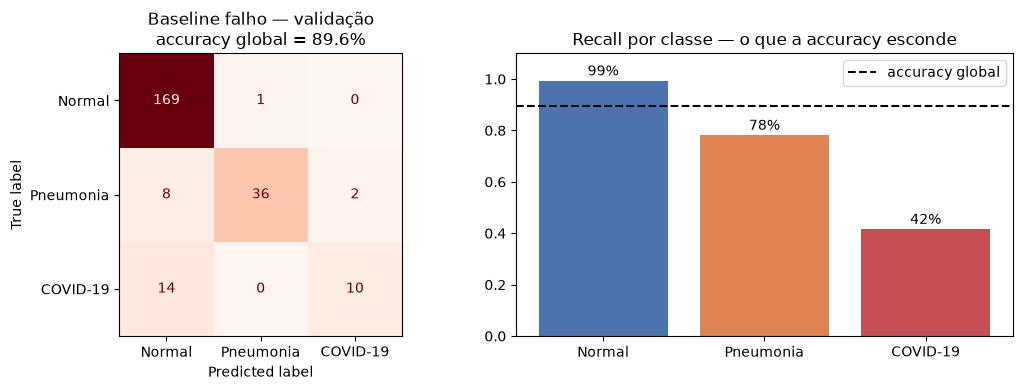

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(bl_va.y, p_va.argmax(1), labels=[0, 1, 2]), display_labels=CLASSES).plot(ax=ax[0], cmap="Reds", colorbar=False)
ax[0].set_title(f"Baseline falho — validação\naccuracy global = {acc_va:.1%}")
rec = confusion_matrix(bl_va.y, p_va.argmax(1), labels=[0, 1, 2], normalize="true").diagonal()
ax[1].bar(CLASSES, rec, color=["#4C72B0", "#DD8452", "#C44E52"]); ax[1].axhline(acc_va, color="k", ls="--", label="accuracy global")
for i, v in enumerate(rec): ax[1].text(i, v + .02, f"{v:.0%}", ha="center")
ax[1].set_ylim(0, 1.1); ax[1].set_title("Recall por classe — o que a accuracy esconde"); ax[1].legend()
plt.tight_layout(); savefig("02_baseline_falho"); plt.show()
baseline_res = dict(acc_treino=acc_tr, acc_val=acc_va, recall_por_classe=dict(zip(CLASSES, rec.round(4))))
del baseline; torch.cuda.empty_cache()

## 4. Split corrigido: estratificado 70/15/15

A partir daqui, todo experimento usa a mesma divisão **estratificada** (Aula 08): treino 840 (588/168/84), validação 180 (126/36/18) e teste 180 (126/36/18). **A GAN só vê o treino**; validação e testes são 100% reais.

*Limitação:* a base não traz identificador de paciente, então não dá para garantir que o mesmo paciente não apareça em dois conjuntos (`GroupKFold` por paciente, Aula 08). Isso fica registrado no plano de melhoria.

In [7]:
i_tr, i_tmp = train_test_split(scen.index, test_size=0.30, stratify=scen.y, random_state=CONFIG["seed"])
i_va, i_te = train_test_split(i_tmp, test_size=0.50, stratify=scen.y[i_tmp], random_state=CONFIG["seed"])
S = {"train": scen.loc[i_tr], "val": scen.loc[i_va], "test": scen.loc[i_te], "test_ampliado": extra}
pd.DataFrame({k: v.label.value_counts().reindex(CLASSES) for k, v in S.items()})

,train,val,test,test_ampliado
label,,,,
Normal,588,126,126,600
Pneumonia,168,36,36,300
COVID-19,84,18,18,600


## 5. GAN condicional (cGAN) para sintetizar raios-X de COVID-19

### Por que uma cGAN (e não CycleGAN)

- Temos só **84 imagens de COVID-19 no treino**. Uma GAN treinada só nelas teria dados de menos para aprender a anatomia do tórax. Uma **GAN condicional** (Mirza & Osindero, 2014; Aula 07) é treinada com as **840** imagens das três classes: a anatomia comum (costelas, coração, diafragma, campos pulmonares) é aprendida com todas, e o rótulo *y* direciona a geração para os padrões de cada classe (no caso da COVID-19, opacidades bilaterais periféricas em vidro fosco).
- A **CycleGAN** (tradução Normal → COVID-19 sem pares) é a alternativa: aproveitaria as Normais abundantes, mas tem dois geradores e dois discriminadores (mais pesada para o T4) e tende a preservar a estrutura da imagem de origem, trocando só a "textura" — o que pode gerar pares quase idênticos a imagens Normais. Fica como alternativa no plano de melhoria.

### Arquitetura (DCGAN condicional, 128×128) — Aula 07

- **Gerador G(z, y):** z ∈ ℝ¹⁰⁰ concatenado ao *embedding* da classe (16-d) → `ConvTranspose2d` (k4, s2) + BatchNorm + ReLU, dobrando a resolução de 4×4 até 128×128 → `Tanh` (pixels em [−1, 1]). Sem camadas densas e sem *pooling* (regras de Radford).
- **Discriminador D(x, y):** a imagem recebe um **mapa espacial aprendido da classe** como segundo canal (1×128×128) → `Conv2d` (k4, s2) + LeakyReLU(0,2) até 4×4 → logit. **Spectral Normalization** em todas as convoluções (Miyato et al., 2018) no lugar de BatchNorm no D: limita a constante de Lipschitz e estabiliza o treino com poucos dados.

### Estabilização — receitas da Aula 07
- **Perda não-saturante:** G minimiza −log D(G(z)) (BCE com rótulo 1), não log(1 − D(G(z))), que satura no início.
- **TTUR:** η_D = 4e-4 > η_G = 1e-4, Adam com β = (0,5; 0,999).
- ***Label smoothing* unilateral:** alvo 0,9 para imagens reais e 0 para falsas (nunca suavizar o falso).
- ***Instance noise*:** ruído gaussiano nas entradas do D (σ de 0,1 a 0 ao longo do treino), que alarga o suporte das distribuições no começo.
- **Amostragem balanceada por classe** nos *batches* da GAN: sem isso, COVID-19 apareceria em só 10% dos *batches* e o gerador mal aprenderia essa classe.

In [8]:
class Generator(nn.Module):
    def __init__(self, nz=100, emb=16, n_cls=3, ngf=32):
        super().__init__()
        self.emb = nn.Embedding(n_cls, emb)
        def up(i, o): return [nn.ConvTranspose2d(i, o, 4, 2, 1, bias=False), nn.BatchNorm2d(o), nn.ReLU(True)]
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz + emb, ngf * 16, 4, 1, 0, bias=False), nn.BatchNorm2d(ngf * 16), nn.ReLU(True),  # 4×4
            *up(ngf * 16, ngf * 8), *up(ngf * 8, ngf * 4), *up(ngf * 4, ngf * 2), *up(ngf * 2, ngf),               # 8 → 64
            nn.ConvTranspose2d(ngf, ngf // 2, 4, 2, 1, bias=False), nn.BatchNorm2d(ngf // 2), nn.ReLU(True),     # 128
            nn.Conv2d(ngf // 2, 1, 3, 1, 1), nn.Tanh())
    def forward(self, z, y):
        return self.net(torch.cat([z, self.emb(y)], 1)[:, :, None, None])

class MinibatchStd(nn.Module):
    """Mitigação de mode collapse (Karras et al., 2018): anexa ao mapa de features um canal com o desvio-padrão médio
    das features ao longo do batch. Se o gerador produz amostras parecidas entre si, o D "vê" a baixa variabilidade
    e consegue penalizá-la — o G passa a ser forçado a diversificar."""
    def forward(self, x):
        std = x.float().std(dim=0, unbiased=False).mean().to(x.dtype)
        return torch.cat([x, std.expand(x.size(0), 1, x.size(2), x.size(3))], dim=1)

class Discriminator(nn.Module):
    """sn=True: Spectral Normalization em todas as convoluções (versão estabilizada).
    sn=False: DCGAN "de livro" (Radford et al.): BatchNorm nas camadas internas, sem SN — usada na ablação.
    mbstd=True: camada minibatch-std antes da última convolução (mitigação de mode collapse)."""
    def __init__(self, n_cls=3, ndf=32, img=128, sn=True, mbstd=False):
        super().__init__()
        self.img = img
        self.label_map = nn.Embedding(n_cls, img * img)
        wrap = spectral_norm if sn else (lambda m: m)
        def down(i, o, bn):
            return [wrap(nn.Conv2d(i, o, 4, 2, 1))] + ([nn.BatchNorm2d(o)] if (bn and not sn) else []) + [nn.LeakyReLU(0.2, True)]
        self.net = nn.Sequential(*down(2, ndf, False), *down(ndf, ndf * 2, True), *down(ndf * 2, ndf * 4, True),
                                 *down(ndf * 4, ndf * 8, True), *down(ndf * 8, ndf * 16, True),
                                 *([MinibatchStd()] if mbstd else []),
                                 wrap(nn.Conv2d(ndf * 16 + int(mbstd), 1, 4, 1, 0)))                           # 128 → 4 → 1
    def forward(self, x, y):
        return self.net(torch.cat([x, self.label_map(y).view(-1, 1, self.img, self.img)], 1)).view(-1)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)) and not hasattr(m, "weight_orig"): nn.init.normal_(m.weight, 0.0, 0.02)
    if isinstance(m, nn.BatchNorm2d): nn.init.normal_(m.weight, 1.0, 0.02); nn.init.zeros_(m.bias)

G, D = Generator(), Discriminator()
G.apply(weights_init); D.apply(weights_init)
print(f"G: {sum(p.numel() for p in G.parameters())/1e6:.2f} M parâmetros | D: {sum(p.numel() for p in D.parameters())/1e6:.2f} M")
with torch.no_grad():
    print("G(z,y):", tuple(G(torch.randn(2, 100), torch.tensor([0, 2])).shape), "| D(x,y):", tuple(D(torch.randn(2, 1, 128, 128), torch.tensor([0, 2])).shape))

G: 3.75 M parâmetros | D: 2.84 M
G(z,y): (2, 1, 128, 128) | D(x,y): (2,)


In [9]:
gc = CONFIG["gan"]
gan_ckpt = DATA_ROOT / "cgan_covid_G.pt"
X_tr = torch.tensor(np.stack(arr(S["train"])), dtype=torch.float32)[:, None] / 127.5 - 1.0     # [-1, 1]
Y_tr = torch.tensor(S["train"].y.values)
cls_w = 1.0 / np.bincount(Y_tr.numpy()); sample_w = cls_w[Y_tr.numpy()]
fixed_z = torch.randn(24, gc["nz"], generator=torch.Generator().manual_seed(0)).to(DEVICE)
fixed_y = torch.arange(3).repeat_interleave(8).to(DEVICE)

def train_cgan(iters, stabilized=True, seed=CONFIG["seed"], log_every=1000, tag="cGAN", mbstd=False):
    """Loop adversarial da cGAN. stabilized=True liga as 4 receitas da Aula 07 (SN no D, TTUR, label smoothing
    unilateral, instance noise); stabilized=False é a DCGAN condicional "de livro" (mesmo LR 2e-4, rótulo 1,0, sem ruído)."""
    seed_everything(seed)
    G, D = Generator(), Discriminator(sn=stabilized, mbstd=mbstd)
    G.apply(weights_init); D.apply(weights_init); G.to(DEVICE); D.to(DEVICE)
    lr_g, lr_d = (gc["lr_g"], gc["lr_d"]) if stabilized else (2e-4, 2e-4)
    real_label, sigma0 = (gc["real_label"], gc["noise_sigma0"]) if stabilized else (1.0, 0.0)
    opt_g = torch.optim.Adam(G.parameters(), lr=lr_g, betas=gc["betas"])
    opt_d = torch.optim.Adam(D.parameters(), lr=lr_d, betas=gc["betas"])
    sampler = torch.utils.data.WeightedRandomSampler(sample_w, num_samples=iters * gc["batch"], replacement=True,
                                                     generator=torch.Generator().manual_seed(seed))
    idx_stream = iter(torch.utils.data.BatchSampler(sampler, gc["batch"], drop_last=True))
    bce = nn.BCEWithLogitsLoss()
    hist, snaps, t0 = [], {}, time.time()
    for it in range(1, iters + 1):
        idx = torch.tensor(next(idx_stream))
        x, y = X_tr[idx].to(DEVICE), Y_tr[idx].to(DEVICE)
        sigma = sigma0 * max(0.0, 1 - it / (0.5 * iters))                       # instance noise com annealing
        z = torch.randn(len(y), gc["nz"], device=DEVICE)
        fake = G(z, y)
        # --- D: reais → real_label (0,9 = label smoothing unilateral), falsas → 0
        d_real = D(x + sigma * torch.randn_like(x), y)
        d_fake = D(fake.detach() + sigma * torch.randn_like(fake), y)
        loss_d = bce(d_real, torch.full_like(d_real, real_label)) + bce(d_fake, torch.zeros_like(d_fake))
        opt_d.zero_grad(set_to_none=True); loss_d.backward(); opt_d.step()
        # --- G: perda não-saturante, −log D(G(z))
        d_gen = D(fake + sigma * torch.randn_like(fake), y)
        loss_g = bce(d_gen, torch.ones_like(d_gen))
        opt_g.zero_grad(set_to_none=True); loss_g.backward(); opt_g.step()
        if it % 50 == 0:
            hist.append(dict(it=it, loss_d=loss_d.item(), loss_g=loss_g.item(),
                             D_real=torch.sigmoid(d_real).mean().item(), D_fake=torch.sigmoid(d_fake).mean().item()))
        if it % log_every == 0 or it in (250, 500):
            G.eval()
            with torch.no_grad(): snaps[it] = G(fixed_z, fixed_y).cpu()
            G.train()
            print(f"[{tag}] it {it:5d} | loss_D {loss_d.item():.3f} loss_G {loss_g.item():.3f} | D(real) {torch.sigmoid(d_real).mean():.2f} "
                  f"D(fake) {torch.sigmoid(d_fake).mean():.2f} | σ {sigma:.3f} | {time.time()-t0:.0f}s")
    return G.eval(), pd.DataFrame(hist), snaps

if gan_ckpt.exists():
    G.load_state_dict(torch.load(gan_ckpt, map_location="cpu")); G.to(DEVICE)
    gan_hist = pd.read_csv(gan_ckpt.with_suffix(".csv")); snapshots = torch.load(gan_ckpt.with_suffix(".snap.pt"))
    print("checkpoint do gerador carregado:", gan_ckpt)
else:
    G, gan_hist, snapshots = train_cgan(gc["iters"], stabilized=True)
    torch.save(G.state_dict(), gan_ckpt); gan_hist.to_csv(gan_ckpt.with_suffix(".csv"), index=False); torch.save(snapshots, gan_ckpt.with_suffix(".snap.pt"))
G.eval()

checkpoint do gerador carregado:

 .\data\cgan_covid_G.pt


Generator(
  (emb): Embedding(3, 16)
  (net): Sequential(
    (0): ConvTranspose2d(116, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 32, kernel_size=(4, 

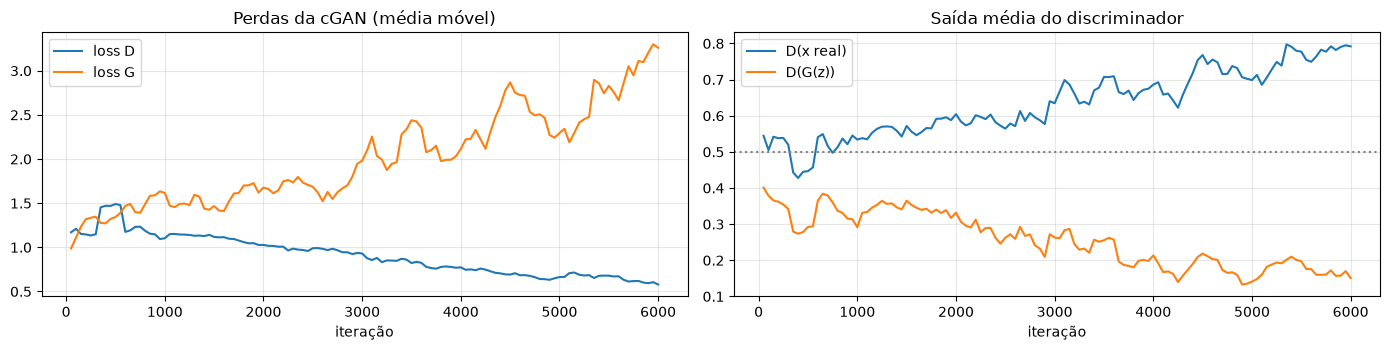

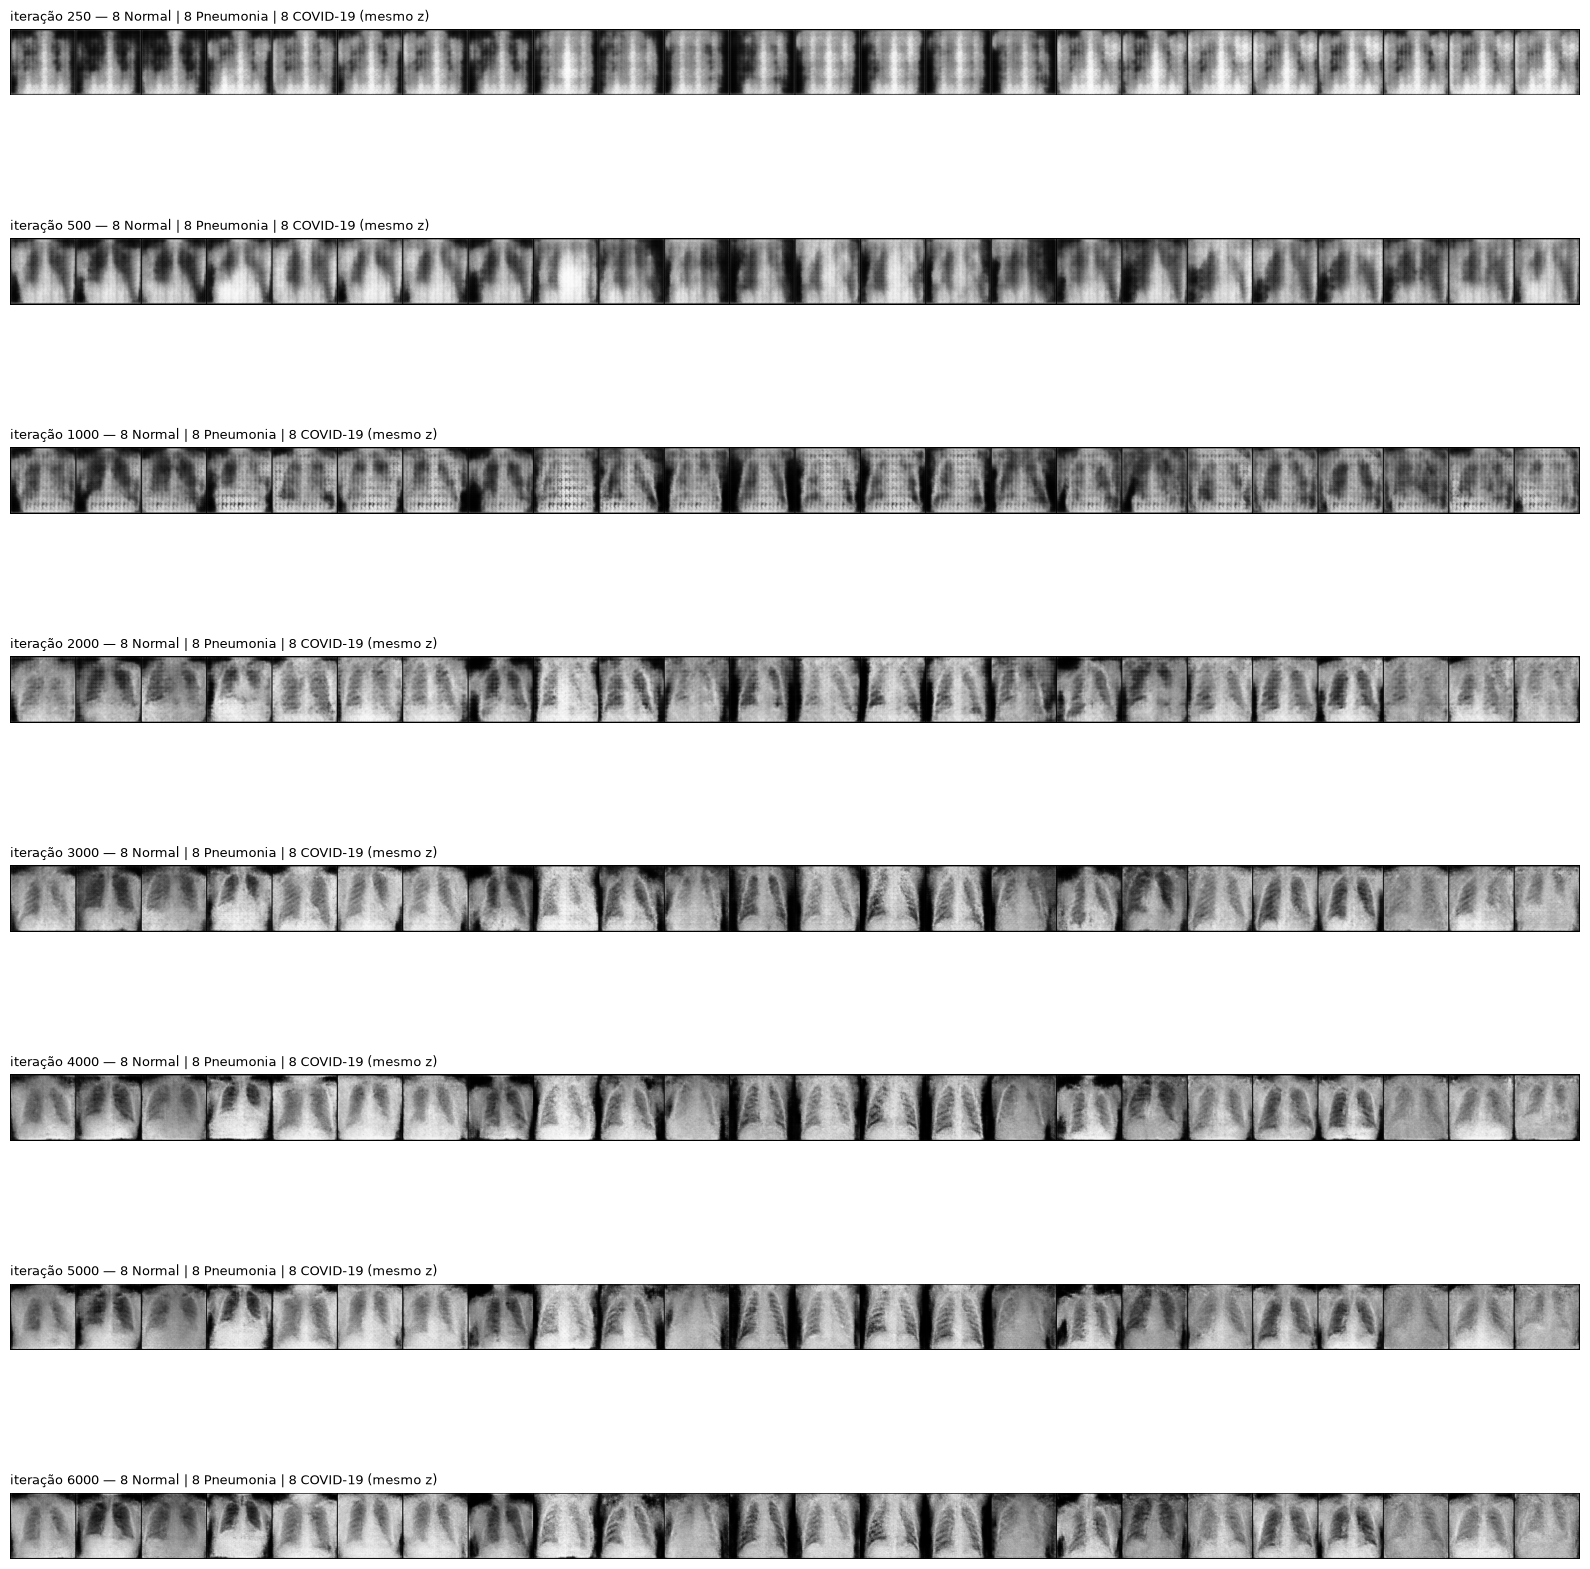

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
roll = lambda s: s.rolling(5, min_periods=1).mean()
ax[0].plot(gan_hist.it, roll(gan_hist.loss_d), label="loss D"); ax[0].plot(gan_hist.it, roll(gan_hist.loss_g), label="loss G")
ax[0].set_title("Perdas da cGAN (média móvel)"); ax[0].set_xlabel("iteração"); ax[0].legend()
ax[1].plot(gan_hist.it, roll(gan_hist.D_real), label="D(x real)"); ax[1].plot(gan_hist.it, roll(gan_hist.D_fake), label="D(G(z))")
ax[1].axhline(0.5, color="gray", ls=":"); ax[1].set_title("Saída média do discriminador"); ax[1].set_xlabel("iteração"); ax[1].legend()
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); savefig("03_gan_perdas"); plt.show()

its = sorted(snapshots)
fig, axes = plt.subplots(len(its), 1, figsize=(16, 2.2 * len(its)))
for a, it in zip(axes, its):
    grid = torchvision.utils.make_grid(snapshots[it], nrow=24, normalize=True, value_range=(-1, 1), padding=2)
    a.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray"); a.axis("off"); a.set_title(f"iteração {it} — 8 Normal | 8 Pneumonia | 8 COVID-19 (mesmo z)", fontsize=9, loc="left")
plt.tight_layout(); savefig("04_gan_evolucao"); plt.show()

### Imagens sintéticas vs reais e checagem de *mode collapse*

*Mode collapse* (Aula 07) aparece como imagens quase idênticas dentro de um mesmo *batch* ("batch clone syndrome"). Além da inspeção visual, medimos a **diversidade**: distância média entre pares de sintéticas, comparada com a mesma medida entre reais de treino.

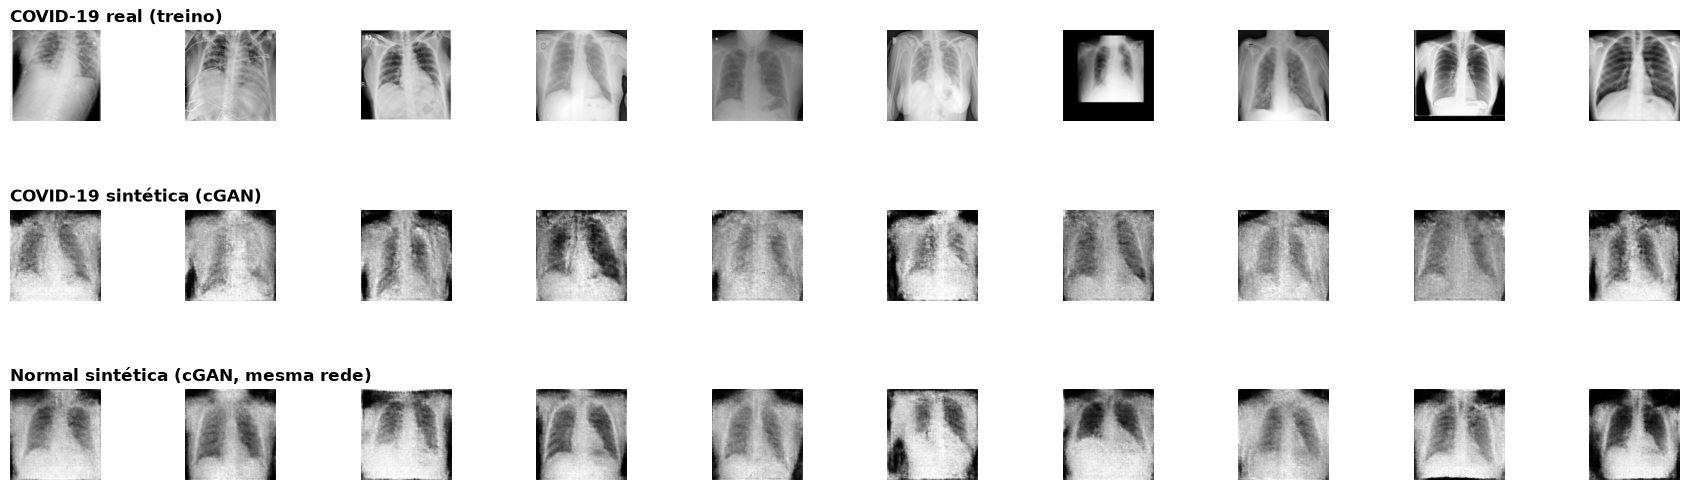

diversidade (MSE médio entre pares) — reais COVID treino: 0.0741 | sintéticas COVID: 0.0429


In [11]:
@torch.no_grad()
def generate(n, cls, seed):
    g = torch.Generator(device=DEVICE).manual_seed(seed); out = []
    for i in range(0, n, 256):
        k = min(256, n - i)
        z = torch.randn(k, CONFIG["gan"]["nz"], device=DEVICE, generator=g)
        out.append(G(z, torch.full((k,), cls, device=DEVICE)).cpu())
    x = torch.cat(out)
    return ((x.clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)[:, 0].numpy()     # uint8 128×128, como as reais

covid_idx = CLASSES.index("COVID-19")
synth_pool = generate(max(CONFIG["synth_sizes"].values()), covid_idx, seed=123)
real_covid_tr = np.stack(arr(S["train"][S["train"].label == "COVID-19"]))

fig, axes = plt.subplots(3, 10, figsize=(17, 5.6))
for j in range(10):
    axes[0, j].imshow(real_covid_tr[j], cmap="gray"); axes[1, j].imshow(synth_pool[j], cmap="gray")
    axes[2, j].imshow(generate(1, 0, seed=500 + j)[0], cmap="gray")
for a in axes.ravel(): a.axis("off")
axes[0, 0].set_title("COVID-19 real (treino)", loc="left", fontweight="bold"); axes[1, 0].set_title("COVID-19 sintética (cGAN)", loc="left", fontweight="bold")
axes[2, 0].set_title("Normal sintética (cGAN, mesma rede)", loc="left", fontweight="bold")
plt.tight_layout(); savefig("05_reais_vs_sinteticas"); plt.show()

def mean_pairwise(a, n=300, seed=0):
    r = np.random.default_rng(seed); x = a[r.choice(len(a), min(n, len(a)), replace=False)].reshape(min(n, len(a)), -1).astype(np.float32) / 255
    sq = (x ** 2).sum(1); d = (sq[:, None] + sq[None] - 2 * x @ x.T) / x.shape[1]       # MSE entre pares via produto interno
    return d[np.triu_indices(len(x), 1)].mean()
print(f"diversidade (MSE médio entre pares) — reais COVID treino: {mean_pairwise(real_covid_tr):.4f} | sintéticas COVID: {mean_pairwise(synth_pool):.4f}")

### Memorização: as sintéticas são cópias do treino?

Uma GAN treinada com poucas imagens pode simplesmente **decorar** o treino — nesse caso as "novas" imagens não trazem informação nova. Para cada sintética, buscamos a imagem real de COVID-19 de treino mais próxima (MSE em pixels) e comparamos com a distância de imagens reais **de validação/teste** ao treino (referência do que é "uma imagem nova").

MSE até o vizinho mais próximo no treino — sintéticas: mediana 0.0151 (mín 0.0056) | reais não vistas: mediana 0.0278 (mín 0.0092)


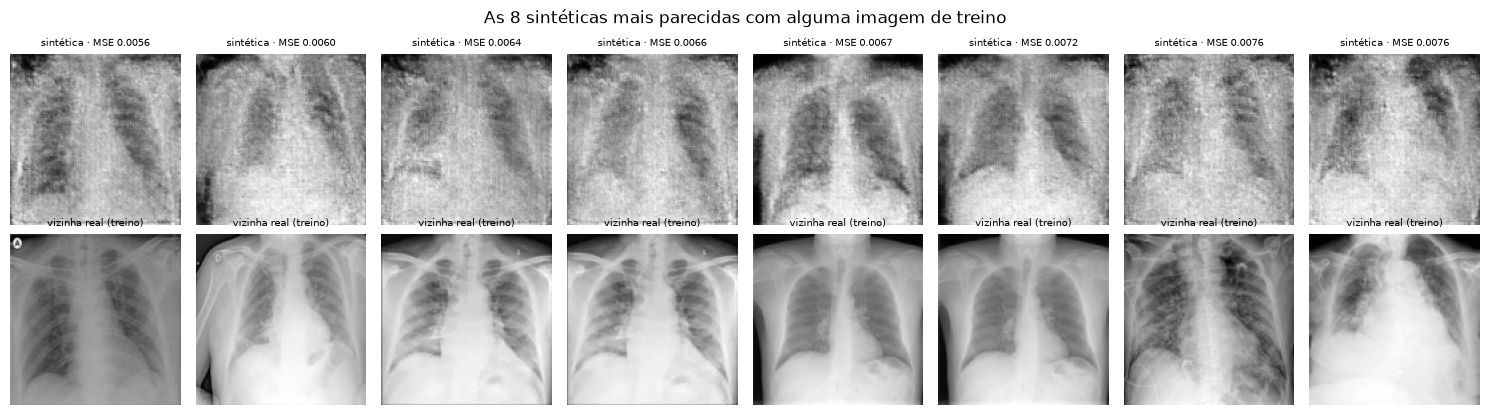

In [12]:
def nn_dist(q, ref):
    q = q.reshape(len(q), -1).astype(np.float32) / 255; r = ref.reshape(len(ref), -1).astype(np.float32) / 255
    d = (q ** 2).sum(1)[:, None] + (r ** 2).sum(1)[None] - 2 * q @ r.T
    return d.min(1) / q.shape[1], d.argmin(1)

d_syn, nn_idx = nn_dist(synth_pool, real_covid_tr)
real_heldout = np.stack(arr(pd.concat([S["val"], S["test"]]).query("label == 'COVID-19'")))
d_real, _ = nn_dist(real_heldout, real_covid_tr)
print(f"MSE até o vizinho mais próximo no treino — sintéticas: mediana {np.median(d_syn):.4f} (mín {d_syn.min():.4f}) | "
      f"reais não vistas: mediana {np.median(d_real):.4f} (mín {d_real.min():.4f})")
fig, axes = plt.subplots(2, 8, figsize=(15, 4.2))
for j, k in enumerate(np.argsort(d_syn)[:8]):
    axes[0, j].imshow(synth_pool[k], cmap="gray"); axes[0, j].set_title(f"sintética · MSE {d_syn[k]:.4f}", fontsize=7)
    axes[1, j].imshow(real_covid_tr[nn_idx[k]], cmap="gray"); axes[1, j].set_title("vizinha real (treino)", fontsize=7)
for a in axes.ravel(): a.axis("off")
plt.suptitle("As 8 sintéticas mais parecidas com alguma imagem de treino"); plt.tight_layout(); savefig("06_memorizacao"); plt.show()

### FID e KID (torch-fidelity)

FID compara média e covariância das features de 2048 dimensões do Inception-v3 (Aula 08). **Ressalva obrigatória:** o FID é enviesado para cima com N pequeno (E[FID_N] = FID_∞ + C/N; a aula recomenda N ≥ 10.000) e aqui só existem **84** COVID-19 reais de treino. Por isso reportamos **N** e também o **KID** (Kernel Inception Distance), não enviesado para N pequeno. Para dar escala aos números, calculamos as mesmas métricas entre **conjuntos reais** (COVID-19 de treino × COVID-19 do teste ampliado; COVID-19 × Normal).

In [13]:
class U8DS(torch.utils.data.Dataset):
    def __init__(self, a): self.a = a
    def __len__(self): return len(self.a)
    def __getitem__(self, i): return torch.from_numpy(self.a[i])[None].repeat(3, 1, 1)     # uint8 [3, H, W]

real_covid_extra = np.stack(arr(S["test_ampliado"][S["test_ampliado"].label == "COVID-19"]))
real_normal_tr = np.stack(arr(S["train"][S["train"].label == "Normal"]))
pairs = {"sintéticas COVID × reais COVID (treino)": (synth_pool, real_covid_tr),
         "reais COVID (teste ampliado) × reais COVID (treino)": (real_covid_extra, real_covid_tr),
         "reais Normal (treino) × reais COVID (treino)": (real_normal_tr, real_covid_tr)}
fid_rows = []
for name, (a, b) in pairs.items():
    m = torch_fidelity.calculate_metrics(input1=U8DS(a), input2=U8DS(b), fid=True, kid=True, kid_subset_size=min(50, len(a), len(b)),
                                         cuda=DEVICE == "cuda", verbose=False, save_cpu_ram=os.name == "nt")   # Windows: sem workers
    fid_rows.append(dict(comparação=name, N1=len(a), N2=len(b), FID=m["frechet_inception_distance"],
                         KID_x1000=1000 * m["kernel_inception_distance_mean"]))
fid_tab = pd.DataFrame(fid_rows); fid_tab.round(2)

,comparação,N1,N2,FID,KID_x1000
0,sintéticas COVID × reais COVID (treino),504,84,385.84,463.66
1,reais COVID (teste ampliado) × reais COVID (tr...,600,84,82.94,-1.59
2,reais Normal (treino) × reais COVID (treino),588,84,108.07,26.07


### Instabilidade de treino e mitigação: ablação "DCGAN de livro" × cGAN estabilizada

As receitas de estabilização da Aula 07 foram aplicadas por precaução. Elas **de fato** fazem diferença neste problema? E o *mode collapse* parcial medido acima (as sintéticas são 42% menos diversas que as reais) tem mitigação? Para ter evidência, treinamos do zero **três versões com o mesmo gerador, os mesmos dados, a mesma semente e o mesmo número de iterações** (2.500):

| | DCGAN condicional "de livro" | cGAN estabilizada (a usada no projeto) |
|---|---|---|
| Discriminador | BatchNorm nas camadas internas (Radford et al.) | **Spectral Normalization**, sem BatchNorm |
| Taxas de aprendizado | iguais (2e-4 / 2e-4) | **TTUR** (η_D = 4e-4, η_G = 1e-4) |
| Rótulo das reais | 1,0 | **0,9** (label smoothing unilateral) |
| Instance noise | não | **σ = 0,1 → 0** |

A terceira versão é a **cGAN estabilizada + minibatch-std** (Karras et al., 2018). O D ganha um canal extra com o desvio-padrão das features **ao longo do batch**. Um gerador que produz amostras parecidas entre si passa a ser "visto" e penalizado pelo D. É uma mitigação direta de *mode collapse*: ataca a falta de diversidade, que nenhuma das 4 receitas acima endereça.

Diagnósticos de instabilidade (Aula 07):
- **Divergência / domínio do discriminador:** D(real) → 1 e D(G(z)) → 0 com `loss_G` crescendo — o gerador deixa de receber gradiente útil.
- ***Mode collapse*:** queda da diversidade (MSE médio entre pares de amostras) e aumento de pares quase idênticos ("batch clone syndrome").
- **Qualidade:** KID e FID contra as COVID-19 reais.

In [14]:
abl = {}
for tag, stab, mb in [("DCGAN de livro", False, False), ("cGAN estabilizada", True, False), ("estabilizada + minibatch-std", True, True)]:
    G_abl, h_abl, s_abl = train_cgan(gc["ablation_iters"], stabilized=stab, log_every=500, tag=tag, mbstd=mb)
    with torch.no_grad():
        g = torch.Generator(device=DEVICE).manual_seed(321)
        z = torch.randn(300, gc["nz"], device=DEVICE, generator=g)
        xs = ((G_abl(z, torch.full((300,), covid_idx, device=DEVICE)).clamp(-1, 1) + 1) * 127.5).round().to(torch.uint8)[:, 0].cpu().numpy()
    flat = xs.reshape(len(xs), -1).astype(np.float32) / 255
    sq = (flat ** 2).sum(1); dmat = (sq[:, None] + sq[None] - 2 * flat @ flat.T) / flat.shape[1]
    iu = np.triu_indices(len(xs), 1)
    m = torch_fidelity.calculate_metrics(input1=U8DS(xs), input2=U8DS(real_covid_tr), fid=True, kid=True, kid_subset_size=50,
                                         cuda=DEVICE == "cuda", verbose=False, save_cpu_ram=os.name == "nt")
    last = h_abl.tail(10)
    abl[tag] = dict(hist=h_abl, snaps=s_abl, amostras=xs, diversidade=float(dmat[iu].mean()),
                    pares_quase_identicos=float((dmat[iu] < 0.01).mean()), FID=m["frechet_inception_distance"],
                    KID_x1000=1000 * m["kernel_inception_distance_mean"], D_real_final=float(last.D_real.mean()),
                    D_fake_final=float(last.D_fake.mean()), loss_G_final=float(last.loss_g.mean()))
    del G_abl; torch.cuda.empty_cache()

ref_div = mean_pairwise(real_covid_tr)
abl_tab = pd.DataFrame({k: {c: v[c] for c in ["diversidade", "pares_quase_identicos", "FID", "KID_x1000", "D_real_final", "D_fake_final", "loss_G_final"]}
                        for k, v in abl.items()}).T
abl_tab.loc["referência: COVID-19 reais (treino)", "diversidade"] = ref_div
abl_tab.round(4)

[DCGAN de livro] it   250 | loss_D 1.160 loss_G 1.926 | D(real) 0.54 D(fake) 0.29 | σ 0.000 | 45s


[DCGAN de livro] it   500 | loss_D 0.873 loss_G 2.055 | D(real) 0.71 D(fake) 0.36 | σ 0.000 | 75s


[DCGAN de livro] it  1000 | loss_D 0.694 loss_G 1.626 | D(real) 0.64 D(fake) 0.17 | σ 0.000 | 149s


[DCGAN de livro] it  1500 | loss_D 0.475 loss_G 3.532 | D(real) 0.82 D(fake) 0.20 | σ 0.000 | 209s


[DCGAN de livro] it  2000 | loss_D 0.564 loss_G 2.559 | D(real) 0.64 D(fake) 0.03 | σ 0.000 | 268s


...

[estabilizada + minibatch-std] it  1000 | loss_D 1.025 loss_G 1.686 | D(real) 0.63 D(fake) 0.36 | σ 0.020 | 134s


[estabilizada + minibatch-std] it  1500 | loss_D 1.068 loss_G 1.928 | D(real) 0.63 D(fake) 0.39 | σ 0.000 | 200s


[estabilizada + minibatch-std] it  2000 | loss_D 0.937 loss_G 1.629 | D(real) 0.58 D(fake) 0.25 | σ 0.000 | 270s


[estabilizada + minibatch-std] it  2500 | loss_D 0.891 loss_G 1.641 | D(real) 0.58 D(fake) 0.22 | σ 0.000 | 344s


,diversidade,pares_quase_identicos,FID,KID_x1000,D_real_final,D_fake_final,loss_G_final
DCGAN de livro,0.0843,0.0003,316.3867,338.8276,0.8629,0.1011,3.7771
cGAN estabilizada,0.0428,0.0029,427.4218,523.1488,0.6180,0.3258,1.8284
estabilizada + minibatch-std,0.0469,0.0027,353.0000,397.4070,0.6325,0.2952,1.6917
referência: COVID-19 reais (treino),0.0741,NaN,NaN,NaN,NaN,NaN,NaN


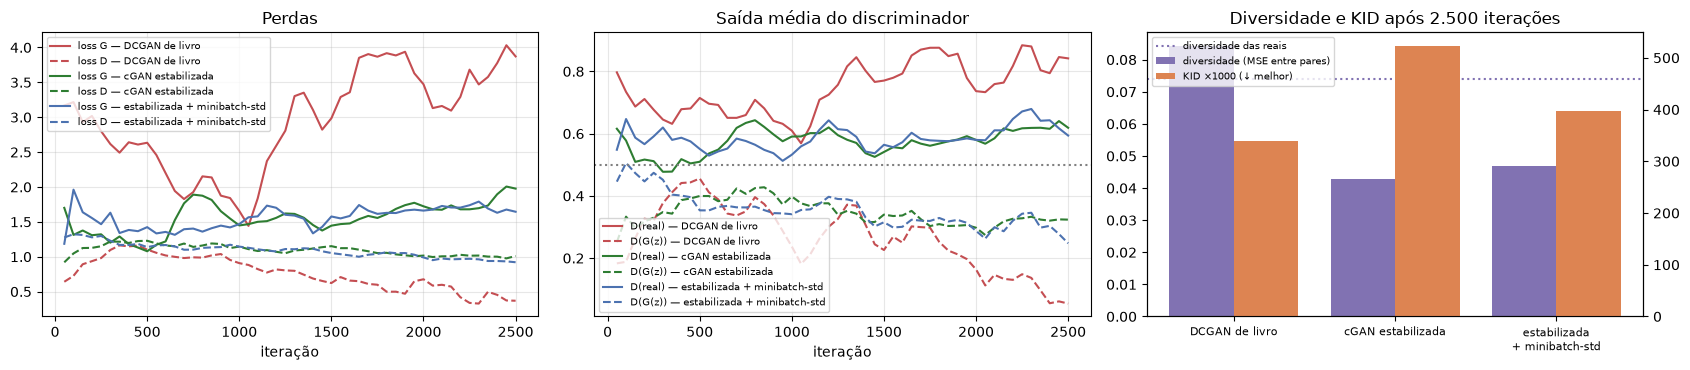

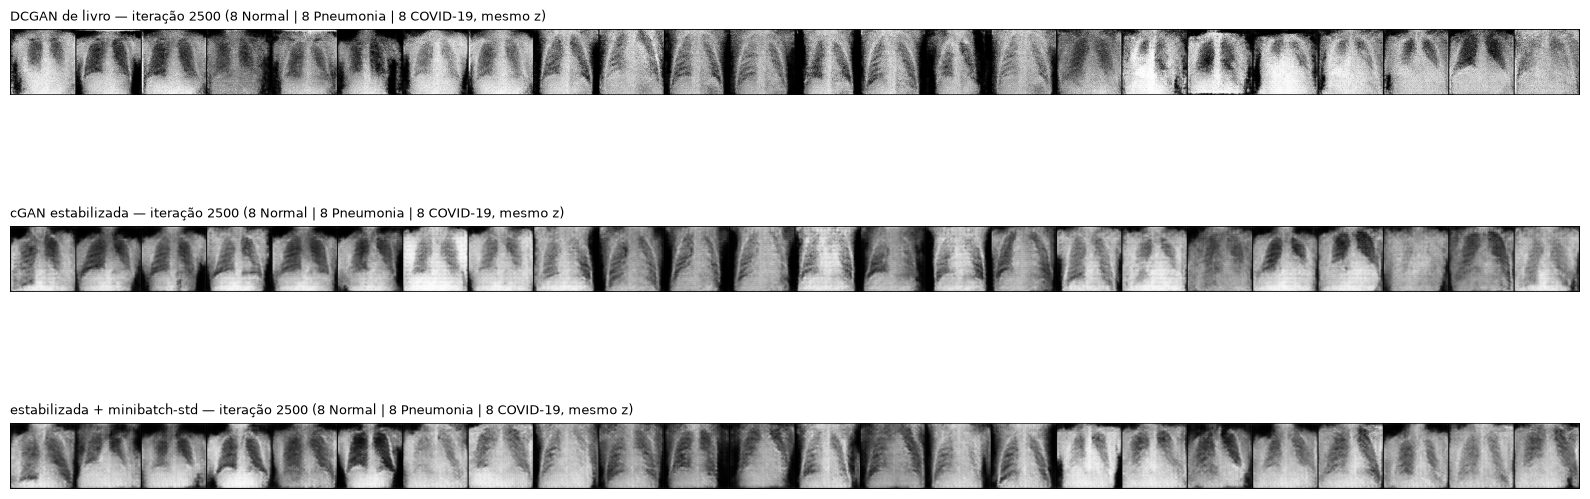

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
for (tag, r), col in zip(abl.items(), ["#C44E52", "#2E7D32", "#4C72B0"]):
    h = r["hist"]
    ax[0].plot(h.it, roll(h.loss_g), color=col, label=f"loss G — {tag}"); ax[0].plot(h.it, roll(h.loss_d), color=col, ls="--", label=f"loss D — {tag}")
    ax[1].plot(h.it, roll(h.D_real), color=col, label=f"D(real) — {tag}"); ax[1].plot(h.it, roll(h.D_fake), color=col, ls="--", label=f"D(G(z)) — {tag}")
ax[0].set_title("Perdas"); ax[1].set_title("Saída média do discriminador"); ax[1].axhline(0.5, color="gray", ls=":")
for a in ax[:2]: a.set_xlabel("iteração"); a.legend(fontsize=7); a.grid(alpha=.3)
names = list(abl); x = np.arange(len(names))
ax[2].bar(x - 0.2, [abl[n]["diversidade"] for n in names], 0.4, label="diversidade (MSE entre pares)", color="#8172B2")
ax[2].axhline(ref_div, color="#8172B2", ls=":", label="diversidade das reais")
ax2 = ax[2].twinx(); ax2.bar(x + 0.2, [abl[n]["KID_x1000"] for n in names], 0.4, color="#DD8452", label="KID ×1000 (↓ melhor)")
ax[2].set_xticks(x, [n.replace(" + ", "\n+ ") for n in names], fontsize=8); ax[2].set_title("Diversidade e KID após 2.500 iterações")
h1, l1 = ax[2].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax[2].legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")
plt.tight_layout(); savefig("06b_ablacao_estabilizacao_curvas"); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(16, 6.9))
for a, (tag, r) in zip(axes, abl.items()):
    it_last = max(r["snaps"])
    grid = torchvision.utils.make_grid(r["snaps"][it_last], nrow=24, normalize=True, value_range=(-1, 1), padding=2)
    a.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray"); a.axis("off")
    a.set_title(f"{tag} — iteração {it_last} (8 Normal | 8 Pneumonia | 8 COVID-19, mesmo z)", fontsize=9, loc="left")
plt.tight_layout(); savefig("06c_ablacao_estabilizacao_amostras"); plt.show()

**Diagnóstico 1: divergência na DCGAN "de livro".** O discriminador **domina** o jogo:
- a `loss_D` cai continuamente (de ~1 para ~0,4, e 0,14 no último log);
- D(real) sobe para ~0,86 e D(G(z)) despenca para ~0,05–0,10;
- a `loss_G` sobe de ~2,5 para ~4 e oscila.

É o quadro de divergência da Aula 07: com D quase perfeito, o gradiente que chega ao gerador fica ruidoso e o equilíbrio de Nash (D ≈ 0,5) se afasta. As amostras confirmam um **ruído granular** forte. (O "MSE entre pares" desta versão sai alto porque esse ruído também infla a métrica de diversidade, um limite dessa métrica em pixels.)

**Mitigação 1 (SN + TTUR + label smoothing + instance noise): o jogo fica equilibrado.** Na versão estabilizada:
- a `loss_D` fica estável em ~1,0–1,1 (perto do −log 4 ≈ 1,39 do equilíbrio, Aula 07);
- D(real) ≈ 0,6 e D(G(z)) ≈ 0,3, sem tendência;
- a `loss_G` estável em ~1,5–1,8.

**Evidência de melhoria na dinâmica de treino:** nenhum dos sinais de divergência aparece. **Custo observado:** com η_G = 1e-4, o gerador aprende mais devagar. Após as mesmas 2.500 iterações, o KID é **pior** (523 contra 339 da versão de livro), e a diversidade fica em **58% da das imagens reais** (0,043 contra 0,074). Isso é um ***mode collapse* parcial**: as amostras ficam "médias" e parecidas, o mesmo problema medido no gerador final.

**Diagnóstico 2 e mitigação 2: minibatch-std contra o *mode collapse*.** Adicionando a camada minibatch-std ao discriminador estabilizado, com todo o resto igual:

| Métrica (2.500 iterações) | Estabilizada | **+ minibatch-std** | Variação |
|---|---|---|---|
| Diversidade (MSE entre pares; reais = 0,074) | 0,043 | **0,047** | **+10%** |
| KID ×1000 (↓) | 523 | **397** | **−24%** |
| FID (↓; N = 300 × 84, enviesado) | 427 | **353** | **−17%** |
| D(real) / D(G(z)) finais | 0,62 / 0,33 | 0,63 / 0,30 | equilíbrio mantido |

**A mitigação funciona no problema diagnosticado:** mais diversidade e amostras mais próximas da distribuição real, **sem** perder a estabilidade conquistada pela mitigação 1.

**Leitura honesta e próximos passos.**
1. Em 2.500 iterações, a versão de livro ainda tem o melhor KID. A divergência dela aparece nas **curvas** (D saturando, `loss_G` subindo), mas ainda não destruiu as amostras. A prova definitiva exigiria treinos mais longos.
2. O gerador usado no experimento de recall (6.000 iterações, sem minibatch-std) é anterior a esta ablação. O passo seguinte seria retreiná-lo com minibatch-std e medir o ΔRecall, com o critério de adoção da seção 9.
3. A diversidade medida em pixels é sensível a ruído. O KID é o indicador mais confiável aqui.

## 6. Experimento: recall de COVID-19 com × sem imagens sintéticas

**Classificador corrigido (igual em todas as condições):**
- ResNet-18 **pré-treinada no ImageNet** (`IMAGENET1K_V1`) — corrige o treino do zero com 840 imagens (Aula 01); a ResNet-18 é mantida para isolar o efeito das outras mudanças.
- Entrada 128×128 em cinza → 3 canais → 224 → normalização ImageNet.
- **Augmentation clinicamente válida:** rotação ±10°, *random resized crop* leve (escala 0,85–1), brilho/contraste ±10%. **Sem flip horizontal**: o coração fica à esquerda, e espelhar cria anatomia impossível (Aula 08).
- AdamW com LR diferencial (backbone 1e-4, cabeça 1e-3), *cosine*, 12 épocas; seleção da época pelo **macro-F1 de validação** (não pela accuracy).

**Condições (só o conjunto de treino muda; validação e testes são sempre 100% reais):**

| | treino | COVID-19 no treino |
|---|---|---|
| **A** | só reais | 84 |
| **B1** | reais + 252 COVID-19 sintéticas | 336 (≈ 2× Pneumonia) |
| **B2** | reais + 504 COVID-19 sintéticas | 588 (= Normal: classes balanceadas) |
| **C** | só reais + *loss* ponderada por classe | 84 (referência sem GAN) |

Cada condição é treinada com **3 sementes**; reportamos média ± desvio. Métrica principal: **recall de COVID-19** e **ΔRecall = Recall_B − Recall_A** (Aula 08).

In [16]:
tf_train = T.Compose([T.RandomRotation(10), T.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
                      T.ColorJitter(brightness=0.1, contrast=0.1), T.ToTensor(), T.Normalize(MEAN, STD)])

def build_train(cond):
    a, y = arr(S["train"]), list(S["train"].y)
    if cond in CONFIG["synth_sizes"]:
        n = CONFIG["synth_sizes"][cond]; a = a + list(synth_pool[:n]); y = y + [covid_idx] * n
    return a, y

def metrics(y, p):
    pred = p.argmax(1); cm = confusion_matrix(y, pred, labels=[0, 1, 2])
    pr, rc, f1, _ = precision_recall_fscore_support(y, pred, labels=[0, 1, 2], zero_division=0)
    covid_spec = cm[np.ix_([0, 1], [0, 1])].sum() / cm[[0, 1]].sum()           # não-COVID não classificado como COVID
    return dict(acc=accuracy_score(y, pred), bacc=balanced_accuracy_score(y, pred), macro_f1=f1.mean(),
                recall_covid=rc[2], precision_covid=pr[2], f1_covid=f1[2], especificidade_covid=covid_spec,
                recall_pneumonia=rc[1], recall_normal=rc[0])

def train_clf(cond, seed):
    seed_everything(seed); c = CONFIG["clf"]
    a, y = build_train(cond)
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1, progress=False); model.fc = nn.Linear(512, 3); model.to(DEVICE)
    opt = torch.optim.AdamW([{"params": [p for n, p in model.named_parameters() if not n.startswith("fc.")], "lr": c["lr_backbone"]},
                             {"params": model.fc.parameters(), "lr": c["lr_head"]}], weight_decay=c["wd"])
    dl = torch.utils.data.DataLoader(XrayDS(a, y, tf_train), batch_size=c["batch"], shuffle=True,
                                     generator=torch.Generator().manual_seed(seed))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[c["lr_backbone"], c["lr_head"]], total_steps=c["epochs"] * len(dl), pct_start=0.1)
    weight = torch.tensor(len(y) / (3 * np.bincount(y)), dtype=torch.float32, device=DEVICE) if cond == "C" else None
    hist, best = [], None
    for ep in range(1, c["epochs"] + 1):
        model.train(); tl = 0
        for x, yy in dl:
            x, yy = x.to(DEVICE), yy.to(DEVICE)
            with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
                loss = F.cross_entropy(model(x).float(), yy, weight=weight)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step(); sched.step(); tl += loss.item() * len(yy)
        pv = predict(model, arr(S["val"]), S["val"].y); mv = metrics(S["val"].y.values, pv)
        hist.append(dict(epoch=ep, train_loss=tl / len(y), val_loss=F.nll_loss(torch.log(torch.tensor(pv) + 1e-9), torch.tensor(S["val"].y.values)).item(), **{f"val_{k}": v for k, v in mv.items()}))
        if best is None or mv["macro_f1"] > best[0]: best = (mv["macro_f1"], copy.deepcopy(model.state_dict()), ep)
    model.load_state_dict(best[1])
    out = dict(cond=cond, seed=seed, best_epoch=best[2], n_train=len(y))
    probs = {k: predict(model, arr(S[k]), S[k].y) for k in ["test", "test_ampliado"]}
    for k in probs: out.update({f"{k}_{m}": v for m, v in metrics(S[k].y.values, probs[k]).items()})
    del model; torch.cuda.empty_cache()
    return out, pd.DataFrame(hist), probs

runs, hists, probs_all, t0 = [], {}, {}, time.time()
for cond in ["A", "B1", "B2", "C"]:
    for seed in CONFIG["clf"]["seeds"]:
        r, h, pr = train_clf(cond, seed); runs.append(r); hists[(cond, seed)] = h; probs_all[(cond, seed)] = pr
        print(f"{cond} seed {seed} | época {r['best_epoch']:2d} | teste: recall COVID {r['test_recall_covid']:.3f} macro-F1 {r['test_macro_f1']:.3f} | "
              f"ampliado: recall COVID {r['test_ampliado_recall_covid']:.3f} macro-F1 {r['test_ampliado_macro_f1']:.3f} | {time.time()-t0:.0f}s")
runs = pd.DataFrame(runs); runs.to_csv(FIG_DIR / "runs.csv", index=False)

A seed 0 | época  9 | teste: recall COVID 0.889 macro-F1 0.919 | ampliado: recall COVID 0.818 macro-F1 0.915 | 70s


A seed 1 | época 10 | teste: recall COVID 0.944 macro-F1 0.930 | ampliado: recall COVID 0.827 macro-F1 0.916 | 142s


A seed 2 | época  7 | teste: recall COVID 0.944 macro-F1 0.935 | ampliado: recall COVID 0.833 macro-F1 0.921 | 217s


B1 seed 0 | época  6 | teste: recall COVID 0.722 macro-F1 0.922 | ampliado: recall COVID 0.673 macro-F1 0.869 | 312s


B1 seed 1 | época  7 | teste: recall COVID 0.833 macro-F1 0.938 | ampliado: recall COVID 0.697 macro-F1 0.865 | 405s


...

B2 seed 1 | época  8 | teste: recall COVID 1.000 macro-F1 0.960 | ampliado: recall COVID 0.813 macro-F1 0.907 | 669s


B2 seed 2 | época  4 | teste: recall COVID 0.944 macro-F1 0.932 | ampliado: recall COVID 0.728 macro-F1 0.873 | 756s


C seed 0 | época 10 | teste: recall COVID 0.833 macro-F1 0.919 | ampliado: recall COVID 0.812 macro-F1 0.916 | 814s


C seed 1 | época 10 | teste: recall COVID 0.889 macro-F1 0.928 | ampliado: recall COVID 0.812 macro-F1 0.915 | 871s


C seed 2 | época  6 | teste: recall COVID 0.778 macro-F1 0.915 | ampliado: recall COVID 0.767 macro-F1 0.903 | 929s


### 6.1 Resultados agregados (média ± desvio em 3 sementes)

In [17]:
cols = ["recall_covid", "precision_covid", "f1_covid", "especificidade_covid", "recall_pneumonia", "recall_normal", "macro_f1", "bacc", "acc"]
def agg(prefix):
    g = runs.groupby("cond")[[f"{prefix}_{c}" for c in cols]]
    t = g.mean().round(3).astype(str) + " ± " + g.std().round(3).astype(str)
    t.columns = cols; return t.loc[["A", "B1", "B2", "C"]]
print("TESTE DO CENÁRIO (180 imagens; 18 COVID-19)"); display_t = agg("test"); print(display_t.to_string())
print("\nTESTE AMPLIADO (1.500 imagens reais não usadas; 600 COVID-19)"); print(agg("test_ampliado").to_string())

TESTE DO CENÁRIO (180 imagens; 18 COVID-19)
       recall_covid precision_covid       f1_covid especificidade_covid recall_pneumonia  recall_normal       macro_f1           bacc            acc
cond                                                                                                                                                
A     0.926 ± 0.032    0.88 ± 0.053  0.901 ± 0.011        0.986 ± 0.007    0.907 ± 0.042  0.963 ± 0.009  0.928 ± 0.008  0.932 ± 0.023  0.948 ± 0.008
B1     0.852 ± 0.14   0.967 ± 0.058  0.898 ± 0.055        0.996 ± 0.007    0.935 ± 0.042  0.987 ± 0.012   0.94 ± 0.018  0.925 ± 0.043  0.963 ± 0.008
B2    0.963 ± 0.032    0.929 ± 0.03  0.945 ± 0.027        0.992 ± 0.004    0.907 ± 0.042  0.979 ± 0.005  0.951 ± 0.016    0.95 ± 0.02  0.963 ± 0.012
C     0.833 ± 0.056     0.9 ± 0.033  0.865 ± 0.036         0.99 ± 0.004    0.917 ± 0.028  0.974 ± 0.005  0.921 ± 0.006  0.908 ± 0.015  0.948 ± 0.003

TESTE AMPLIADO (1.500 imagens reais não usadas; 600 COVID-19)

In [18]:
delta = []
for split in ["test", "test_ampliado"]:
    a = runs[runs.cond == "A"].set_index("seed")[f"{split}_recall_covid"]
    for cond in ["B1", "B2", "C"]:
        b = runs[runs.cond == cond].set_index("seed")[f"{split}_recall_covid"]
        d = (b - a)
        delta.append(dict(conjunto=split, condição=cond, recall_A=a.mean(), recall_cond=b.mean(), ΔRecall_médio=d.mean(), ΔRecall_por_semente=d.round(3).tolist()))
delta = pd.DataFrame(delta); delta.round(3)

,conjunto,condição,recall_A,recall_cond,ΔRecall_médio,ΔRecall_por_semente
0,test,B1,0.926,0.852,-0.074,"[-0.167, -0.111, 0.056]"
1,test,B2,0.926,0.963,0.037,"[0.056, 0.056, 0.0]"
2,test,C,0.926,0.833,-0.093,"[-0.056, -0.056, -0.167]"
3,test_ampliado,B1,0.826,0.740,-0.086,"[-0.145, -0.13, 0.017]"
4,test_ampliado,B2,0.826,0.798,-0.028,"[0.033, -0.013, -0.105]"
5,test_ampliado,C,0.826,0.797,-0.029,"[-0.007, -0.015, -0.067]"


### 6.2 Intervalo de confiança do ΔRecall (bootstrap)

As três sementes medem a variância do **treino**; o bootstrap mede a variância da **amostra de teste**. Usamos a probabilidade média das 3 sementes de cada condição e reamostramos, 2.000 vezes, as imagens de COVID-19 do teste, calculando o ΔRecall (B − A) em cada reamostragem.

In [19]:
def mean_probs(cond, split): return np.mean([probs_all[(cond, s)][split] for s in CONFIG["clf"]["seeds"]], 0)
rng = np.random.default_rng(0); ci_rows = []
for split in ["test", "test_ampliado"]:
    y = S[split].y.values; pos = np.where(y == covid_idx)[0]
    hitA = mean_probs("A", split).argmax(1)[pos] == covid_idx
    for cond in ["B1", "B2", "C"]:
        hitB = mean_probs(cond, split).argmax(1)[pos] == covid_idx
        boots = [(hitB[s].mean() - hitA[s].mean()) for s in (rng.integers(0, len(pos), len(pos)) for _ in range(2000))]
        ci_rows.append(dict(conjunto=split, condição=cond, n_covid=len(pos), ΔRecall=hitB.mean() - hitA.mean(),
                            IC95_inf=np.percentile(boots, 2.5), IC95_sup=np.percentile(boots, 97.5)))
ci = pd.DataFrame(ci_rows); ci.round(3)

,conjunto,condição,n_covid,ΔRecall,IC95_inf,IC95_sup
0,test,B1,18,-0.056,-0.167,0.000
1,test,B2,18,0.000,0.000,0.000
2,test,C,18,-0.111,-0.278,0.000
3,test_ampliado,B1,600,-0.083,-0.110,-0.057
4,test_ampliado,B2,600,-0.008,-0.033,0.017
5,test_ampliado,C,600,-0.042,-0.060,-0.023


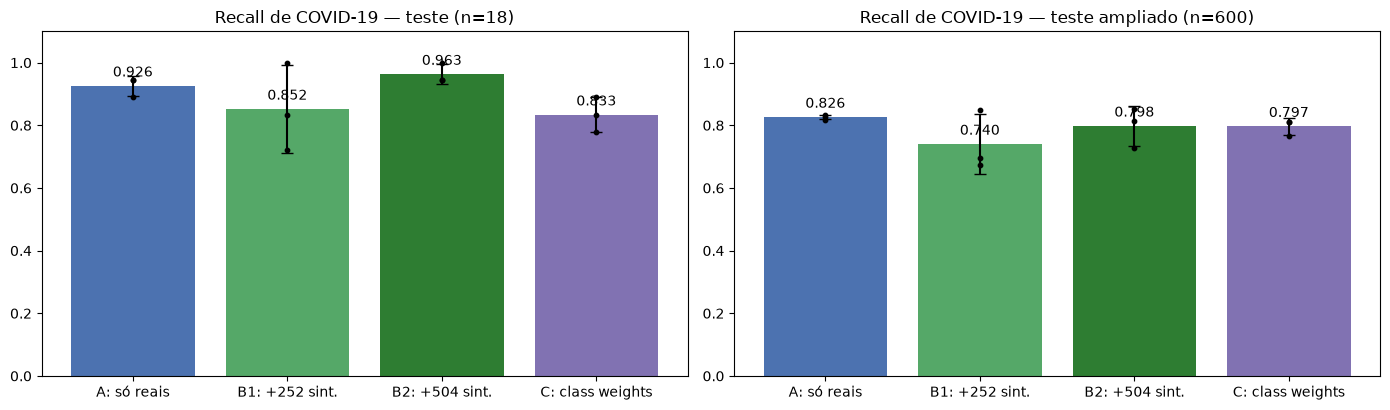

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
order = ["A", "B1", "B2", "C"]; colors = ["#4C72B0", "#55A868", "#2E7D32", "#8172B2"]
for k, split in enumerate(["test", "test_ampliado"]):
    m = runs.groupby("cond")[f"{split}_recall_covid"].mean().loc[order]; s = runs.groupby("cond")[f"{split}_recall_covid"].std().loc[order]
    ax[k].bar(order, m, yerr=s, color=colors, capsize=4)
    for i, v in enumerate(m): ax[k].text(i, v + 0.03, f"{v:.3f}", ha="center")
    ax[k].scatter(np.repeat(range(4), 3), runs.set_index("cond").loc[order, f"{split}_recall_covid"], color="k", s=10, zorder=3)
    ax[k].set_ylim(0, 1.1); ax[k].set_title(f"Recall de COVID-19 — {'teste (n=18)' if split == 'test' else 'teste ampliado (n=600)'}")
    ax[k].set_xticks(range(4), ["A: só reais", "B1: +252 sint.", "B2: +504 sint.", "C: class weights"])
plt.tight_layout(); savefig("07_recall_covid_condicoes"); plt.show()

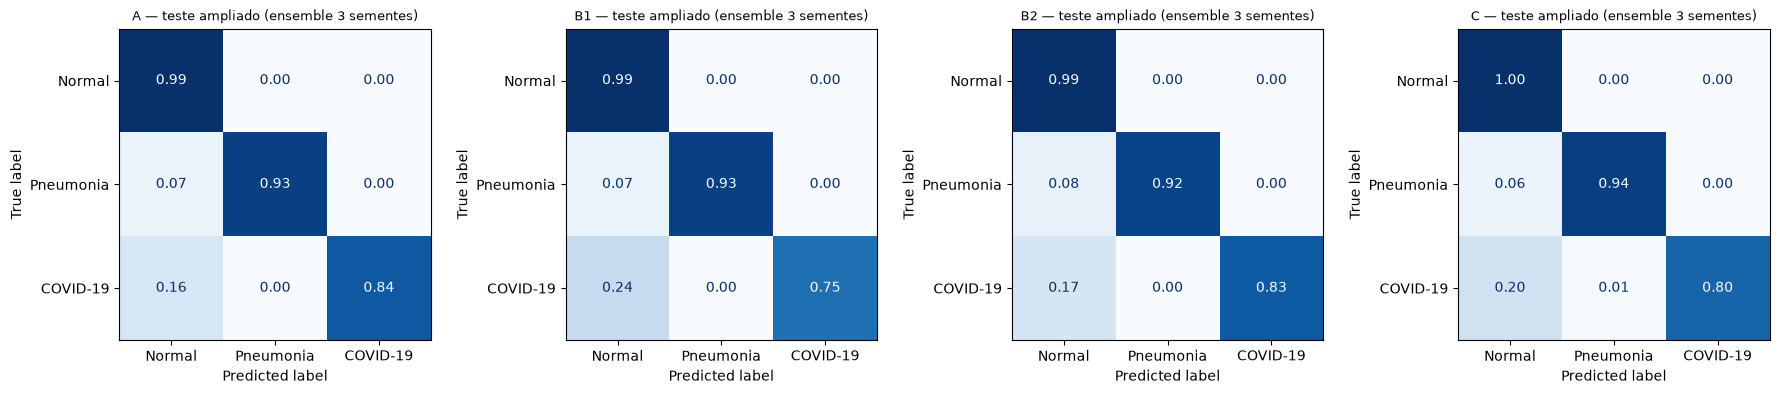

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for a, cond in zip(axes, order):
    p = mean_probs(cond, "test_ampliado")
    ConfusionMatrixDisplay(confusion_matrix(S["test_ampliado"].y, p.argmax(1), labels=[0, 1, 2], normalize="true"),
                           display_labels=CLASSES).plot(ax=a, cmap="Blues", colorbar=False, values_format=".2f")
    a.set_title(f"{cond} — teste ampliado (ensemble 3 sementes)", fontsize=9)
plt.tight_layout(); savefig("08_confusao_condicoes"); plt.show()

### 6.3 Curvas de treino: base (A) × aumentado com GAN (B2)

Comparação das curvas por época (Aula 08): loss de treino, loss de validação e recall de COVID-19 na validação, média das 3 sementes.

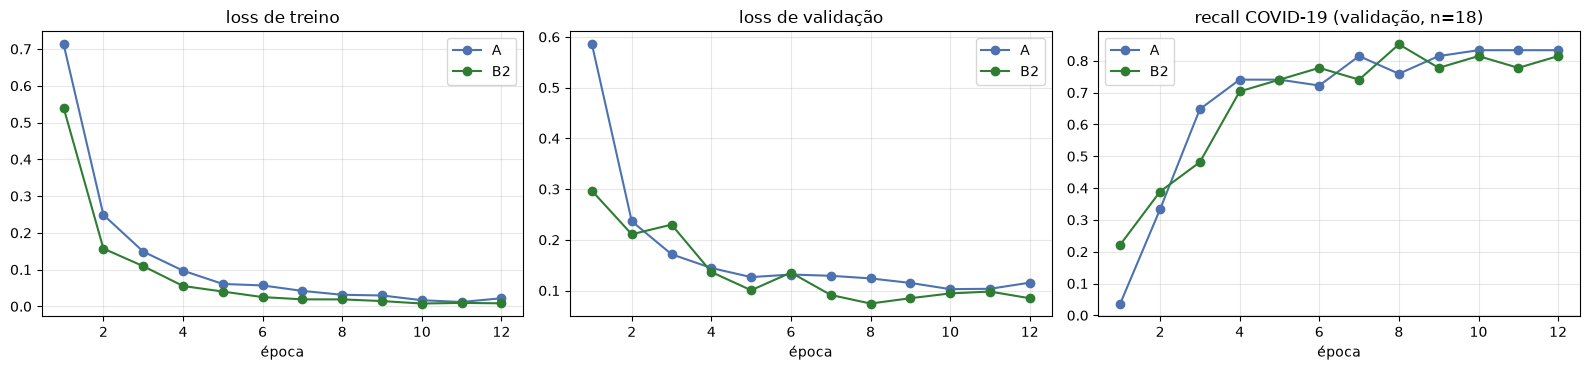

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for cond, col in [("A", "#4C72B0"), ("B2", "#2E7D32")]:
    h = pd.concat([hists[(cond, s)] for s in CONFIG["clf"]["seeds"]]).groupby("epoch").mean()
    ax[0].plot(h.index, h.train_loss, "o-", color=col, label=cond); ax[1].plot(h.index, h.val_loss, "o-", color=col, label=cond)
    ax[2].plot(h.index, h.val_recall_covid, "o-", color=col, label=cond)
for a, t in zip(ax, ["loss de treino", "loss de validação", "recall COVID-19 (validação, n=18)"]): a.set_title(t); a.set_xlabel("época"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); savefig("09_curvas_A_vs_B2"); plt.show()

## 7. Resultados consolidados

In [23]:
summary = dict(baseline_falho=baseline_res, fid_kid=fid_tab.round(3).to_dict("records"), ablacao_gan=abl_tab.round(4).to_dict("index"),
               memorizacao=dict(mse_nn_sinteticas_mediana=float(np.median(d_syn)), mse_nn_reais_nao_vistas_mediana=float(np.median(d_real))),
               teste=agg("test").to_dict("index"), teste_ampliado=agg("test_ampliado").to_dict("index"),
               delta_recall=delta.round(4).to_dict("records"), ic_bootstrap=ci.round(4).to_dict("records"))
(FIG_DIR / "results.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
print(json.dumps(summary, indent=2, ensure_ascii=False, default=str))

{
  "baseline_falho": {
    "acc_treino": 0.9979166666666667,
    "acc_val": 0.8958333333333334,
    "recall_por_classe": {
      "Normal": 0.9941,
      "Pneumonia": 0.7826,
      "COVID-19": 0.4167
    }
  },
  "fid_kid": [
    {
      "comparação": "sintéticas COVID × reais COVID (treino)",
      "N1": 504,
      "N2": 84,
      "FID": 385.835,
      "KID_x1000": 463.663
    },
    {
      "comparação": "reais COVID (teste ampliado) × reais COVID (treino)",
      "N1": 600,
      "N2": 84,
      "FID": 82.944,
      "KID_x1000": -1.586
    },
    {
      "comparação": "reais Normal (treino) × reais COVID (treino)",
      "N1": 588,
      "N2": 84,
      "FID": 108.074,
      "KID_x1000": 26.07
    }
  ],
  "ablacao_gan": {
    "DCGAN de livro": {
      "diversidade": 0.0843,
      "pares_quase_identicos": 0.0003,
      "FID": 316.3867,
      "KID_x1000": 338.8276,
      "D_real_final": 0.8629,
      "D_fake_final": 0.1011,
      "loss_G_final": 3.7771
    },
    "cGAN estabilizada":

## 8. Análise dos resultados

### 8.1 O baseline reproduz a queixa clínica

Com a configuração original, o modelo chega a **99,8% de accuracy no treino e 89,6% na validação**, um número que parece "promissor". Na validação, porém, o **recall de COVID-19 é 41,7%**: 14 de cada 24 pacientes com COVID-19 seriam liberados como "Normal". Normal tem 99,4% de recall e Pneumonia 78,3%. É exatamente o que o time clínico descreveu ("ignora casos positivos") e o padrão citado no enunciado (recall < 60% para a classe minoritária sob accuracy alta).

A accuracy global é dominada pela classe Normal (70% dos dados) e esconde a falha. Por sorte, a validação sem estratificação recebeu exatamente 24 COVID-19 (10%), mas outra semente poderia sortear 15 ou 30 e mudar a conclusão.

### 8.2 A maior parte do ganho vem de corrigir o pipeline, não da GAN

A condição **A** (só imagens reais, mas com pré-treino ImageNet, augmentation clinicamente válida, split estratificado, AdamW com *one-cycle* e seleção por macro-F1) leva o recall de COVID-19 de **41,7% para 92,6% ± 3,2%** no teste do cenário e **82,6% ± 0,8%** no teste ampliado (600 COVID-19 reais). Precisão de COVID-19 0,99 e especificidade 0,99. Essas correções dos problemas 1–8 resolvem a maior parte do "ignora positivos".

A diferença entre os dois testes (92,6% vs 82,6%) mostra **por que o teste ampliado era necessário**: com 18 COVID-19, uma única imagem muda o recall em 5,6 p.p., e o teste pequeno foi otimista.

### 8.3 Efeito das imagens sintéticas: ΔRecall

| Condição | Recall COVID (teste, n=18) | ΔRecall | Recall COVID (ampliado, n=600) | ΔRecall | IC 95% bootstrap (ampliado) |
|---|---|---|---|---|---|
| A: só reais | 0,926 ± 0,032 | — | 0,826 ± 0,008 | — | — |
| B1: +252 sintéticas | 0,852 ± 0,140 | −0,074 | 0,740 ± 0,096 | **−0,086** | [−0,110; −0,057] |
| B2: +504 sintéticas | 0,963 ± 0,032 | +0,037 | 0,798 ± 0,063 | −0,028 | [−0,033; +0,017] |
| C: *class weights* | 0,833 ± 0,056 | −0,093 | 0,797 ± 0,026 | −0,029 | [−0,060; −0,023] |

**Leitura honesta:** **as imagens da cGAN não melhoraram o recall de COVID-19.**
- B2 parece ganhar 3,7 p.p. no teste de 18 imagens, mas isso é menos de uma imagem em média. No teste ampliado o efeito é −2,8 p.p., com intervalo de confiança contendo zero.
- B1 piora de forma **significativa** (−8,6 p.p.; o IC não contém zero).
- A variância entre sementes cresce muito com sintéticas: ±9,6 p.p. em B1 contra ±0,8 p.p. em A. O resultado passa a depender da sorte da inicialização.
- Nas matrizes de confusão, os erros de COVID-19 vão **todos para "Normal"** (16% em A, 24% em B1), nunca para Pneumonia. Ou seja, são exatamente os falsos negativos clinicamente perigosos.

### 8.4 Por que a GAN não ajudou: as métricas generativas explicam

- **FID/KID:**
  - entre sintéticas COVID-19 e reais COVID-19, **FID = 386 e KID = 0,464**;
  - entre dois conjuntos **reais** de COVID-19, **FID = 83 e KID ≈ 0** (o FID de 83 é inflado pelo N pequeno, como alerta a Aula 08; o KID não enviesado confirma distâncias iguais);
  - entre **Normal e COVID-19 reais**, o FID é 108.

  **As sintéticas estão mais longe das COVID-19 reais do que as radiografias Normais estão.** Visualmente, a anatomia é plausível (campos pulmonares, costelas, coração, diafragma), mas a imagem tem uma **textura granulada de alta frequência** que nenhuma radiografia real tem.
- **Diversidade:** o MSE médio entre pares de sintéticas é 0,043, contra 0,074 entre reais. A cGAN gera **42% menos variedade**. Não há colapso total, mas há *mode collapse* parcial (Aula 07).
- **Memorização:** as sintéticas **não** são cópias do treino. As vizinhas mais próximas são visivelmente outras imagens. A distância menor ao treino (0,015 contra 0,028 das reais não vistas) reflete imagens "médias" e suavizadas, que ficam perto de tudo em MSE.
- **Mecanismo provável do efeito negativo:** só a classe COVID-19 recebe sintéticas. O classificador aprende que **"textura de GAN" ⇒ COVID-19**, um atalho que não existe nas imagens reais de teste. O conceito de COVID-19 do modelo se desloca para o domínio sintético. A **precisão** de COVID-19 sobe (0,987 → 0,994) e o **recall cai**: o modelo fica mais "exigente" para chamar uma imagem real de COVID-19. É o risco que a Aula 07 aponta: realismo estatístico insuficiente vira ruído ou atalho, e por isso a validação pelo recall *downstream* é obrigatória.
- A referência sem GAN (C, pesos por classe) também não superou A. Com pré-treino e augmentation, o desbalanceamento 7:1 já não é o gargalo principal **nesta base**. O gargalo é a qualidade da evidência visual das COVID-19 reais.

### 8.5 Limitações deste experimento
- **Viés de fonte:** as COVID-19 vêm de repositórios (BIMCV, Eurorad, GitHub, SIRM) diferentes das Normais e Pneumonias (Kaggle/RSNA e base pediátrica). Parte do desempenho pode vir de reconhecer a **fonte**. Os 82,6% de recall não estimam o desempenho em outro hospital.
- Sem identificador de paciente, não dá para garantir a separação por paciente.
- GAN treinada uma vez, com uma configuração. GANs são sensíveis a hiperparâmetros, e outra arquitetura poderia ter outro resultado (ver plano).
- 3 sementes por condição. Mais sementes estreitariam os intervalos.

## 9. Plano de melhoria integrado

O plano endereça os 10 problemas da seção 2, em ordem de prioridade, e incorpora o que este experimento mostrou.

**Fase 1: dados e protocolo (antes de qualquer modelo)**
1. **Coleta e curadoria** *(problemas 4 e 9)*:
   - montar a base com identificador de paciente, hospital e equipamento;
   - buscar COVID-19 e controles **das mesmas instituições**, para quebrar a correlação fonte↔classe;
   - registrar metadados clínicos (RT-PCR como padrão-ouro).
2. **Divisão correta** *(5 e 8)*:
   - treino/validação/teste **estratificados por classe e agrupados por paciente** (`StratifiedGroupKFold`);
   - **teste externo** de outro hospital, usado uma única vez.
3. **Métricas clínicas** *(6 e 10)*:
   - métrica primária: **sensibilidade (recall) de COVID-19**, com especificidade, F1 por classe, balanced accuracy, matriz de confusão e intervalos de confiança;
   - **limiar calibrado na validação** para uma sensibilidade-alvo definida com o time clínico (ex.: ≥ 95%), com a especificidade resultante reportada.

**Fase 2: modelo** *(problemas 1, 2, 3 e 7)*
4. **Transfer learning:** ResNet-18/50 ou ViT pré-treinados, com *fine-tuning* com LR diferencial. Considerar também backbones pré-treinados em radiografia de tórax.
5. **Augmentation clinicamente válida:** rotação e translação leves, recorte leve, brilho/contraste/gama. **Sem flip horizontal.**
6. **Otimização:** AdamW + *cosine/one-cycle*, *early stopping* e seleção pela métrica clínica na validação. Repetir com várias sementes.

**Fase 3: escassez da classe COVID-19** *(problema 4)*. O experimento mostrou que **dados sintéticos de baixa fidelidade pioram o recall**. A ordem recomendada é:

7. Começar pelo que funcionou e é barato: pré-treino + augmentation, depois *class weights* ou *oversampling*, sempre comparados por ΔRecall.
8. Se for usar GAN, **subir a régua de qualidade antes de usar as imagens**:
   - arquitetura e regularização para poucos dados (StyleGAN2-ADA / DiffAugment), resolução ≥ 256;
   - **CycleGAN Normal→COVID-19**, que preserva a textura real e só altera achados, com λ_cyc = 10 e λ_idt = 5 (Aula 07);
   - **critério de aceite:** FID/KID das sintéticas comparável ao de reais×reais, *precision/recall* generativos e inspeção por radiologista;
   - filtrar sintéticas pela confiança de um classificador treinado só com reais;
   - aplicar a mesma "assinatura" de textura às reais e sintéticas (ou um filtro passa-baixa), para que a origem não vire atalho;
   - validar sempre pelo **ΔRecall no teste real**, com IC (Aula 08), e descartar a abordagem se o IC não excluir zero a favor.

**Fase 4: confiabilidade e implantação** *(problema 9)*
9. **Auditoria de atalhos:** mapas de atenção/Grad-CAM nos falsos negativos e positivos; testes com bordas e marcações mascaradas.
10. **Validação clínica prospectiva:** uso como **triagem assistida**, não diagnóstico, com revisão humana dos negativos de baixa confiança, monitoramento de *drift* por hospital e equipamento, e retreino periódico.

**Critério de adoção clínica (go/no-go).** O modelo só entra em uso assistido se cumprir **todos** os itens abaixo no **teste externo multicêntrico**, definidos com o time clínico **antes** de ver os resultados:

| Critério | Limite proposto | Por quê |
|---|---|---|
| Sensibilidade (recall) de COVID-19 no limiar operacional | ≥ 95%, com **limite inferior do IC 95% ≥ 90%** | Em triagem, o falso negativo libera um paciente infectado; o IC impede aprovar por sorte num teste pequeno |
| Especificidade de COVID-19 | ≥ 85% | Limita os falsos alarmes (isolamento e testes desnecessários) a um volume que o serviço comporta |
| Desempenho por subgrupo (hospital, equipamento, idade, sexo) | nenhum subgrupo com sensibilidade < 90% | Evita um modelo que funciona "na média" mas falha num hospital, que é o risco do viés de fonte |
| Calibração | erro de calibração (ECE) ≤ 0,05 | A probabilidade precisa ser confiável para o limiar e para a revisão humana dos casos intermediários |
| Não inferioridade | sensibilidade ≥ à do fluxo atual (radiologista ou triagem clínica) no mesmo conjunto | O sistema precisa agregar valor ao processo atual, não só ter um número alto |
| Auditoria de atalhos | mapas de atenção/Grad-CAM nos FN e FP sem foco sistemático em marcações, bordas ou texto | Garante que a decisão vem do pulmão, não da fonte da imagem |
| Dados sintéticos | só se **ΔRecall > 0 com IC excluindo zero** no teste real | Neste projeto, as sintéticas da cGAN **não** passariam nesse critério |
| Fase silenciosa (*silent trial*) | 4–8 semanas rodando em paralelo, sem afetar condutas, com os critérios acima mantidos | Confirma o desempenho com dados de produção antes de qualquer impacto clínico |

Se qualquer critério falhar, o modelo volta para a Fase 1/2. Depois de adotado, o monitoramento contínuo usa os mesmos limites como gatilho de retreino ou desligamento.